# Analysis of Outcomes Data for Graduates

This project is about the analysis of outcomes data for graduates who had obtained a qualification in certain STEM subject areas from UK education providers.

#### <u> Dataset attribution statement </u>
Credit for the dataset used in this project goes to HESA (Higher Education Statistics Agency, website: www.hesa.ac.uk). The dataset is licensed under the Creative Commons Attribution 4.0 International (CC-BY-4.0) license. Please view the details for this license via the following link: https://creativecommons.org/licenses/by/4.0/legalcode.

The dataset was obtained from HESA via the following link:
https://www.hesa.ac.uk/data-and-analysis/graduates/table-30
using the 'download source data' link on the webpage. The dataset's title is: `UK permanent address graduates in full-time paid employment in the UK by subject area of degree, salary band, country of provider, provider type, level of qualification obtained, mode of former study, skill group, work population marker and academic year`.

The transformations I have applied to the dataset are stated and/ or shown within this notebook.

Please also refer to the project's README for further details about attribution and licensing.

## <u> Setup and overview <u>

In [1]:
# Import libraries and packages
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import sklearn
import warnings

In [2]:
%matplotlib inline

The following are the subject areas of interest in this analysis: `Physical sciences`, `Mathematical sciences`, `Engineering and technology`, `Computing`, and `Architecture, building and planning`.

In [3]:
# Import the dataset, including only subject areas of interest
# The source data includes tables for a range of academic years - only data for academic year 2017/18 is used below.
subject_rows_salary = range(134684, 256334) # rows containing data about subjects of interest only
header = 13 # header row index
salary_df = pd.read_csv('data/table-30-2017-18.csv', skiprows = lambda x: x not in subject_rows_salary and x != header, low_memory= False)
display(salary_df.shape)

(121650, 11)

#### Head

In [4]:
# Salary DataFrame header
salary_df.head(5)

,Subject area of degree,Country of provider,Provider type,Level of qualification obtained,Mode of former study,Skill group,Work population marker,Salary band,Academic year,Number,Percent
0,07 Physical sciences,All,All,All,All,All,Paid employment is an activity,"Less than £15,000",2017/18,95,2%
1,07 Physical sciences,All,All,All postgraduate,All,All,Paid employment is an activity,"Less than £15,000",2017/18,10,1%
2,07 Physical sciences,All,All,All undergraduate,All,All,Paid employment is an activity,"Less than £15,000",2017/18,85,3%
3,07 Physical sciences,All,All,First degree,All,All,Paid employment is an activity,"Less than £15,000",2017/18,80,3%
4,07 Physical sciences,All,All,Other undergraduate,All,All,Paid employment is an activity,"Less than £15,000",2017/18,10,5%


#### Dropping the 'Percent' column

Individual rows in this dataset represent multiple graduates. The `Number` column shows the number of graduates in a row.  The '`Percent`' column shows the quantity of graduates in a row as a percentage of graduates at all `Salary bands`, who share the same values for the remaining variables in the row.

In [5]:
# Dropping the Percent column
salary_df = salary_df.drop(columns = "Percent")

#### Discarding redundant aggregate data

The dataset consists of aggregated data.

As shown above, individual rows represent multiple graduates.

Additionally, many of the variables include an 'All' category, as shown in the value counts below. These 'All' categories are redundant and may be removed from the dataset so that only rows with more specific values for each of the variables are included.

The '`Salary band`' variable also includes a 'Total' category, which is shown in the value counts below. Rows containing this value will also be removed from the dataset.

Finally, rows containing an 'All undergraduate' or 'All postgraduate' value in the '`Level of qualification obtained`' will also be dropped.

In [6]:
salary_agg = salary_df.copy()

In [7]:
for column in salary_df:
    display(salary_df[column].value_counts())
    print("")

Subject area of degree
11 Computing                              26520
10 Engineering and technology             26160
13 Architecture, building and planning    25200
07 Physical sciences                      23940
09 Mathematical sciences                  19830
Name: count, dtype: int64

Country of provider
All                 31140
England             30660
Wales               22500
Scotland            21150
Northern Ireland    16200
Name: count, dtype: int64

Provider type
All                                  52695
Higher education providers (HEPs)    52695
Further education colleges (FECs)    16260
Name: count, dtype: int64

Level of qualification obtained
All                        21180
All undergraduate          21060
First degree               19740
Other undergraduate        18270
All postgraduate           15720
Postgraduate (taught)      15480
Postgraduate (research)    10200
Name: count, dtype: int64

Mode of former study
All          43140
Full-time    41160
Part-time    37350
Name: count, dtype: int64

Skill group
All               35910
High skilled      35850
Medium skilled    26730
Low skilled       23160
Name: count, dtype: int64

Work population marker
Paid employment is an activity                61080
Paid employment is most important activity    60570
Name: count, dtype: int64

Salary band
Less than £15,000    8110
Total                8110
£15,000 - £17,999    8110
£18,000 - £20,999    8110
£21,000 - £23,999    8110
£24,000 - £26,999    8110
£27,000 - £29,999    8110
£30,000 - £32,999    8110
£33,000 - £35,999    8110
£36,000 - £38,999    8110
£39,000 - £41,999    8110
£42,000 - £44,999    8110
£45,000 - £47,999    8110
£48,000 - £50,999    8110
£51,000+             8110
Name: count, dtype: int64

Academic year
2017/18    121650
Name: count, dtype: int64

Number
0       69695
5       16177
10       6124
15       3722
20       2951
        ...  
3300        1
3225        1
3145        1
2085        1
1345        1
Name: count, Length: 695, dtype: int64

In [8]:
# Removing rows with 'All' under any column/ variable
for column in salary_df.columns:
    rows_delete = salary_df.iloc[salary_df[column] == "All"]
    salary_df.drop(index = rows_delete.index, inplace = True)
print(f"There are now {salary_df.shape[0]} rows and {salary_df.shape[1]} columns")

There are now 17730 rows and 10 columns


In [9]:
# Removing rows with a salary band of 'Total' (i.e. aggregate of all salary bands)
rows_delete = salary_df.iloc[salary_df["Salary band"] == "Total"]
salary_df.drop(index = rows_delete.index, inplace = True)
print(f"There are now {salary_df.shape[0]} rows and {salary_df.shape[1]} columns")

There are now 16548 rows and 10 columns


In [10]:
# Removing rows with a 'Level of qualification obtained' of either 'All undergraduate' or 'All postgraduate'
rows_delete = salary_df.iloc[salary_df["Level of qualification obtained"] == "All undergraduate"]
salary_df.drop(index = rows_delete.index, inplace = True)

rows_delete = salary_df.iloc[salary_df["Level of qualification obtained"] == "All postgraduate"]
salary_df.drop(index = rows_delete.index, inplace = True)
print(f"There are now {salary_df.shape[0]} rows and {salary_df.shape[1]} columns")

There are now 10234 rows and 10 columns


#### Discarding empty rows

The dataset appears to be sparse; the value counts above show that a large number of rows have a count of 0 graduates in the '`Number`' column. Therefore, these rows do not correspond to any graduates, and can be discarded.*

\* *(Technically, these rows may correspond to 1 or 2 graduates. Numbers had been rounded to the nearest multiple of 5 by the dataset's authors, and numbers 1 and 2 had been rounded down to 0.)*

In [11]:
# Drop rows with 0 graduates
empty_rows = salary_df.iloc[salary_df["Number"] == 0]
salary_df.drop(empty_rows.index, inplace = True)
print(f"There are now {salary_df.shape[0]} rows and {salary_df.shape[1]} columns")

There are now 2116 rows and 10 columns


#### Converting variables to numerical format

In [12]:
# Converting 'Academic year' to numerical format (date)
salary_df["Academic year"] = salary_df["Academic year"].str.replace("2017/18", "2017") # replacing the academic year's year range with its start year
salary_df["Academic year"] = salary_df["Academic year"].astype("datetime64[ns]")  # converting string to the datetime64 format
salary_df["Academic year"] = salary_df["Academic year"].apply(lambda x: x.year)  # keeping only the year of the date object (converts to int64 format)

To convert `Salary band` to numerical format, each salary band is replaced with its midpoint, as shown below.

In [13]:
# Converting 'Salary band' to numerical format, using midpoints of each band
salary_band_dict = {}

for band in salary_df["Salary band"].unique():
    band_processed = band.split(" - ") # splits value into two: upper and lower values of band
    band_processed = [val.replace("£", "").replace(",", "").strip() for val in band_processed] # strips '£' symbol, commas and whitespace
    # all bands besides highest and lowest
    if len(band_processed) == 2:
        sal_midpoint = (int(band_processed[0]) + int(band_processed[1])) // 2
    # lowest band
    elif band_processed[0] == "Less than 15000": # threshold used
        sal_midpoint = 14999
    # highest band
    elif band_processed[0] == "51000+": # threshold used
        sal_midpoint = 51000
    else:
        print("error", band_processed)
    salary_band_dict[band] = sal_midpoint # add original & processed values to dict as key, value pair

display(salary_band_dict)

{'£18,000 - £20,999': 19499,
 'Less than £15,000': 14999,
 '£15,000 - £17,999': 16499,
 '£21,000 - £23,999': 22499,
 '£24,000 - £26,999': 25499,
 '£27,000 - £29,999': 28499,
 '£30,000 - £32,999': 31499,
 '£33,000 - £35,999': 34499,
 '£36,000 - £38,999': 37499,
 '£39,000 - £41,999': 40499,
 '£42,000 - £44,999': 43499,
 '£45,000 - £47,999': 46499,
 '£48,000 - £50,999': 49499,
 '£51,000+': 51000}

In the newly-created `salary_band_dict`, the keys show the original salary band, and the values show either the midpoints of the corresponding salary band, or, for highest and lowest salary bands only, the threshold value of the salary band.

Note: In the dataset, graduates earning salaries of £51,000 and higher had been grouped into one category as '£51,000+', while those earning up to £15,000 had been grouped into another category as 'Less than £15,000', i.e. the data is right- and left-censored.<br>

In [14]:
# Converting 'Salary band' to numerical format (cont.)
salary_df_copy = salary_df.replace(to_replace = salary_band_dict) # replaces salary band ranges with midpoints (or thresholds, for highest and lowest bands)
salary_df_copy["Salary band"] = salary_df_copy["Salary band"].astype("Int64") # 'Salary band' column converted from 'object' to Int datatype
salary_df_copy.rename(columns = {"Salary band" : "Salary band midpoint/ threshold"}, inplace = True) # 'Salary band' column renamed to 'Salary band midpoint/ threshold'

#### Variable information

In [15]:
# Viewing data types and non-null counts:
salary_df_copy.info()

<class 'pandas.DataFrame'>
Index: 2116 entries, 9438 to 121330
Data columns (total 10 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   Subject area of degree           2116 non-null   str  
 1   Country of provider              2116 non-null   str  
 2   Provider type                    2116 non-null   str  
 3   Level of qualification obtained  2116 non-null   str  
 4   Mode of former study             2116 non-null   str  
 5   Skill group                      2116 non-null   str  
 6   Work population marker           2116 non-null   str  
 7   Salary band midpoint/ threshold  2116 non-null   Int64
 8   Academic year                    2116 non-null   int64
 9   Number                           2116 non-null   int64
dtypes: Int64(1), int64(2), str(7)
memory usage: 474.4 KB


#### Summary statistics: numerical variables

The three columns with numerical data are currently '`Academic year`', '`Number`' and '`Salary band midpoint/ threshold`'. <br>

In [16]:
# Summary statistics
stat_summary = salary_df_copy.describe()
display(stat_summary)
print(f"NB: the 'min' and 'max' values for 'Salary band midpoint/ threshold' have been censored")

,Salary band midpoint/ threshold,Academic year,Number
count,2116.0,2116.0,2116.000000
mean,30344.995274,2017.0,27.199905
std,10752.623079,0.0,76.792787
min,14999.0,2017.0,5.000000
25%,22499.0,2017.0,5.000000
50%,28499.0,2017.0,5.000000
75%,37499.0,2017.0,20.000000
max,51000.0,2017.0,1225.000000


NB: the 'min' and 'max' values for 'Salary band midpoint/ threshold' have been censored


All rows in this dataset have the same `Academic year`, as expected. <br> <br>
The summary statistics above for `Salary band midpoint` currently do not take into account the `Number` of graduates in each salary band, as the data is currently aggregated. More useful summary statistics may be obtained by disaggregating the data. <br><br>
The maximum `Number` of graduates in a single row is 1225. To check the validity of this large `Number` value, the largest unique `Number` values were examined. A few unique '`Number`' values were larger than 900. The DataFrame was queried to find row with a large `Number` of graduates, which shows that the top three rows (in terms of number of graduates) consist of graduates whose first degree was in Engineering and Technology.

In [17]:
# Top three largest groups of graduates
number_values = sorted(salary_df_copy["Number"].unique(), reverse = True)[0:3]
display(number_values)
salary_df_copy.query("Number == @number_values")

[np.int64(1225), np.int64(1210), np.int64(980)]

,Subject area of degree,Country of provider,Provider type,Level of qualification obtained,Mode of former study,Skill group,Work population marker,Salary band midpoint/ threshold,Academic year,Number
54975,10 Engineering and technology,England,Higher education providers (HEPs),First degree,Full-time,High skilled,Paid employment is an activity,28499,2017,1225
54982,10 Engineering and technology,England,Higher education providers (HEPs),First degree,Full-time,High skilled,Paid employment is an activity,31499,2017,980
55080,10 Engineering and technology,England,Higher education providers (HEPs),First degree,Full-time,High skilled,Paid employment is most important activity,28499,2017,1210


#### Histograms

In [18]:
salary_plot = salary_df_copy.copy()

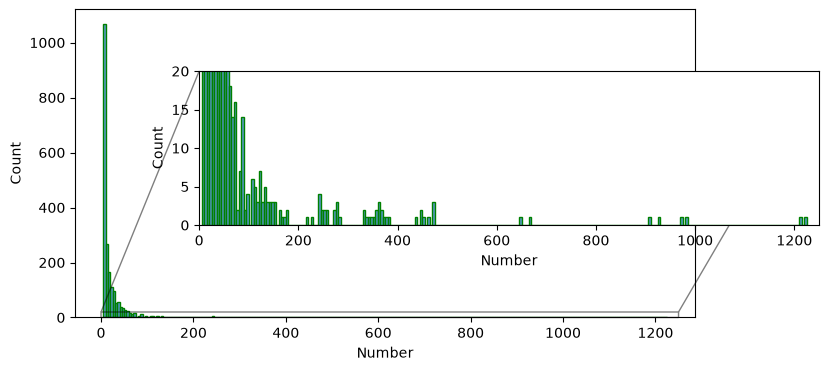

In [19]:
# Histogram: Numbers
warnings.filterwarnings("ignore", category=UserWarning)

fig_num, ax1 = plt.subplots(figsize=(8, 4), sharex=True)
sns.histplot(data=salary_plot["Number"], ax=ax1, binwidth=5, edgecolor="green", linewidth =1) # base plot

inset = ax1.inset_axes([0.2, 0.3, 1, 0.5], xlim=(0, 1250), ylim=(0, 20)) # zoomed plot
sns.histplot(data=salary_plot["Number"], ax=inset, binwidth=5, edgecolor="green", linewidth=1)
ax1.indicate_inset_zoom(inset, edgecolor="black")

for axis in (ax1, inset): # set spine edge colour
    for spine in axis.spines.values():
        spine.set_edgecolor("black")
fig_num.show()

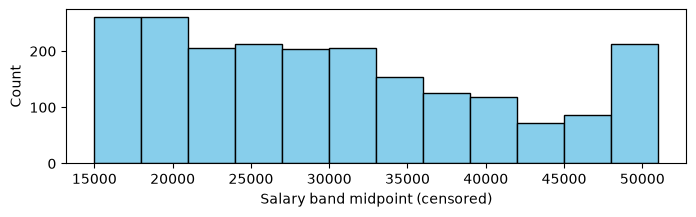

In [20]:
# Histogram: Salary band midpoint
fig_sal, ax = plt.subplots(figsize=(8, 2))
sns.histplot(data=salary_plot, x = salary_plot["Salary band midpoint/ threshold"], binwidth=3000, color = "skyblue", ax=ax, alpha=1)
ax.set(xlabel="Salary band midpoint (censored)")
for spine in ax.spines.values():
    spine.set_edgecolor("black")
fig_sal.show()

The histogram plot of the `Number` variable shows the number of graduates for each row. The most common value for `Number` is 5, indicating that the vast majority of rows had only 5 graduates (numbers had been rounded to the nearest 5 by the dataset authors, therefore each row with `Number` = 5 may correspond to as few as 3 and as many as 7 graduates). However, as shown in the histogram and in the rows returned by the DataFrame query, a few rows had a much higher number of graduates (approx. 1000-1200). Some of these rows correspond to graduates whose first degree was in `Engineering and technology`, and whose salary was close to the median. <br><br>
As all rows represent a group of graduates, the `Salary band midpoint (censored)` data currently shows the count of groups, i.e. rows, with each salary band. (A group may correspond to between 3 and 1227 graduates.)

## <u>Train-test splitting</u>

#### Disaggregating the data
The dataset contains aggregate data, where each row represents a group of graduates. To disaggregate the data, rows may be duplicated using the number of graduates represented by each row (the value in the `Number` column) to produce a DataFrame where each row represents one graduate.

Note: values in the '`Number`' column had been rounded to the nearest 5 for all rows by the dataset's authors. Therefore, rows with a value of '5' for the `Number` variable may actually represent as few as 3 and as many as 7 graduates.

In [21]:
salary_df_copy.info()

<class 'pandas.DataFrame'>
Index: 2116 entries, 9438 to 121330
Data columns (total 10 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   Subject area of degree           2116 non-null   str  
 1   Country of provider              2116 non-null   str  
 2   Provider type                    2116 non-null   str  
 3   Level of qualification obtained  2116 non-null   str  
 4   Mode of former study             2116 non-null   str  
 5   Skill group                      2116 non-null   str  
 6   Work population marker           2116 non-null   str  
 7   Salary band midpoint/ threshold  2116 non-null   Int64
 8   Academic year                    2116 non-null   int64
 9   Number                           2116 non-null   int64
dtypes: Int64(1), int64(2), str(7)
memory usage: 474.4 KB


In [22]:
# Disaggregate data
total_observations = salary_df_copy.shape[0] # the no. of rows in dataset

i = 0
while i < total_observations:
    row = salary_df_copy.iloc[i] # retrieve each row in dataset
    multiply_by = row["Number"] - 2 # calculate no. of copies to make
    row = row.to_frame().T # convert row to DataFrame and transpose

    j = 0
    total_rows = row # create first row
    while j < multiply_by:
        total_rows = pd.concat(objs = [total_rows, row], axis = 0) # replicate row once
        j += 1 # repeat for number of copies needed

    salary_df_copy = pd.concat(objs = [salary_df_copy, total_rows], axis = 0) # add the copies to the original DataFrame
    i += 1 #repeat for all rows in original DataFrame

In [23]:
# Check number of rows in disaggregated data
display(salary_df_copy.duplicated().value_counts())

True     55439
False     2116
Name: count, dtype: int64

In [24]:
# Check total number of graduates in aggregate data
sum(salary_plot["Number"])

57555

In [25]:
# Drop 'Number' column
salary_df_individual = salary_df_copy.drop(columns = "Number")
print(f"There are now {salary_df_individual.shape[0]} rows and {salary_df_individual.shape[1]} columns")

There are now 57555 rows and 9 columns


Each row in the DataFrame now corresponds to approximately one graduate*. The duplicate value count above shows that the new rows have correctly been identified as duplicates.

Additionally, the `Number` column has been dropped as each row now represents one graduate* rather than the number of graduates in `Number`.

\* *Note the rounding strategy implemented by the dataset's authors (referred to above).*

#### Creating a 'Category' column

Below, a new '`Category`' column is created in the dataset, and is assigned the value that is in the index of each row. Each row's index value identifies which group it comes from in the original dataset of aggregate values.

The DataFrame is then re-indexed so that the index starts at 0 and increments by 1 for every observation, in order to work with the test and train index values which are generated later during the train-test splitting process.

In [26]:
# Create a Category column and populate using the index
salary_df_individual["Category"] = salary_df_individual.index
salary_df_individual["Category"] = salary_df_individual["Category"].astype("string")

# Reset index
salary_df_individual.reset_index(inplace = True, drop = True)

#### Splitting the data

The dataset is split so that 10% of observations go to the test set, and 90% go to the training set.

Observations are split using the newly-created '`Category`' column.

In [27]:
from sklearn.model_selection import StratifiedKFold
warnings.filterwarnings("ignore", category=UserWarning)

salary_df_individual2 = salary_df_individual.copy()

# Stratified k-fold split
splitter = StratifiedKFold(n_splits = 10)
for train_index, test_index in splitter.split(salary_df_individual2, salary_df_individual2["Category"]):
    salary_train = salary_df_individual2.loc[train_index]
    salary_test = salary_df_individual2.loc[test_index]

print(f"The training set now has {salary_train.shape[0]} rows and {salary_train.shape[1]} columns.")
print(f"The test set now has {salary_test.shape[0]} rows and {salary_test.shape[1]} columns.")

The training set now has 51800 rows and 10 columns.
The test set now has 5755 rows and 10 columns.


In [28]:
# Relative frequency of values in each column - before train-test split
for col in salary_df_individual.columns:
    display(salary_df_individual[col].value_counts(normalize=True))
    print()

Subject area of degree
10 Engineering and technology             0.393710
11 Computing                              0.223091
13 Architecture, building and planning    0.147424
07 Physical sciences                      0.137868
09 Mathematical sciences                  0.097906
Name: proportion, dtype: float64

Country of provider
England             0.831813
Scotland            0.097211
Wales               0.043958
Northern Ireland    0.027018
Name: proportion, dtype: float64

Provider type
Higher education providers (HEPs)    0.928416
Further education colleges (FECs)    0.071584
Name: proportion, dtype: float64

Level of qualification obtained
First degree               0.680219
Postgraduate (taught)      0.147945
Other undergraduate        0.125793
Postgraduate (research)    0.046043
Name: proportion, dtype: float64

Mode of former study
Full-time    0.791938
Part-time    0.208062
Name: proportion, dtype: float64

Skill group
High skilled      0.893667
Medium skilled    0.073756
Low skilled       0.032578
Name: proportion, dtype: float64

Work population marker
Paid employment is an activity                0.505951
Paid employment is most important activity    0.494049
Name: proportion, dtype: float64

Salary band midpoint/ threshold
25499    0.172270
28499    0.159847
31499    0.152637
22499    0.110850
19499    0.097993
34499    0.079229
37499    0.045348
51000    0.043697
40499    0.035184
16499    0.034923
46499    0.018852
49499    0.018678
43499    0.016767
14999    0.013726
Name: proportion, dtype: float64

Academic year
2017    1.0
Name: proportion, dtype: float64

Category
54975     0.021284
55080     0.021023
54982     0.017027
55087     0.016853
54968     0.016072
            ...   
121307    0.000087
121314    0.000087
121321    0.000087
121327    0.000087
121330    0.000087
Name: proportion, Length: 2116, dtype: double[pyarrow]

In [29]:
# Relative frequency of values in each column - test set
for col in salary_test.columns:
    display(salary_test[col].value_counts(normalize=True))
    print()

Subject area of degree
10 Engineering and technology             0.393745
11 Computing                              0.223110
13 Architecture, building and planning    0.147350
07 Physical sciences                      0.137793
09 Mathematical sciences                  0.098002
Name: proportion, dtype: float64

Country of provider
England             0.831625
Scotland            0.097307
Wales               0.043962
Northern Ireland    0.027107
Name: proportion, dtype: float64

Provider type
Higher education providers (HEPs)    0.928584
Further education colleges (FECs)    0.071416
Name: proportion, dtype: float64

Level of qualification obtained
First degree               0.683579
Postgraduate (taught)      0.146829
Other undergraduate        0.123197
Postgraduate (research)    0.046394
Name: proportion, dtype: float64

Mode of former study
Full-time    0.792181
Part-time    0.207819
Name: proportion, dtype: float64

Skill group
High skilled      0.893658
Medium skilled    0.073675
Low skilled       0.032667
Name: proportion, dtype: float64

Work population marker
Paid employment is an activity                0.506169
Paid employment is most important activity    0.493831
Name: proportion, dtype: float64

Salary band midpoint/ threshold
25499    0.171677
28499    0.160382
31499    0.151868
22499    0.111381
19499    0.097307
34499    0.080799
37499    0.044831
51000    0.043267
40499    0.035621
16499    0.035274
46499    0.019114
49499    0.018245
43499    0.016855
14999    0.013380
Name: proportion, dtype: float64

Academic year
2017    1.0
Name: proportion, dtype: float64

Category
54975     0.021199
55080     0.021025
54982     0.017029
55087     0.016855
54968     0.015986
            ...   
121223    0.000174
121300    0.000174
121314    0.000174
121327    0.000174
121328    0.000174
Name: proportion, Length: 1586, dtype: double[pyarrow]

The relative frequencies of the values for each column in the test set are similar to those which were in the dataset before splitting.

In [30]:
# Unique 'Category' values in the test set
print(f"{len(salary_test["Category"].unique()) / len(salary_df_individual["Category"].unique()):.4f}")

0.7495


As shown above, 74.95% of the unique '`Category`' values which were in the dataset before the train-test split are now in the test set. Each unique '`Category`' value comes from a distinct row in the original aggregated dataset, and represents a distinct combination of values from the columns.

In [31]:
# Drop Category column
for dataframe in [salary_train, salary_test, salary_df_individual, salary_df_individual2]:
    dataframe.drop(columns = "Category", inplace = True)

In [32]:
# Display training set
salary_train.head(5)

,Subject area of degree,Country of provider,Provider type,Level of qualification obtained,Mode of former study,Skill group,Work population marker,Salary band midpoint/ threshold,Academic year
0,07 Physical sciences,England,Further education colleges (FECs),Other undergraduate,Full-time,High skilled,Paid employment is an activity,19499,2017
1,07 Physical sciences,England,Further education colleges (FECs),Other undergraduate,Full-time,High skilled,Paid employment is most important activity,19499,2017
2,07 Physical sciences,England,Higher education providers (HEPs),First degree,Full-time,High skilled,Paid employment is an activity,14999,2017
3,07 Physical sciences,England,Higher education providers (HEPs),Postgraduate (taught),Full-time,High skilled,Paid employment is an activity,14999,2017
4,07 Physical sciences,England,Higher education providers (HEPs),First degree,Full-time,High skilled,Paid employment is an activity,16499,2017


## <u>Exploratory Data Analysis (EDA)</u>

In [33]:
salary_explore = salary_train.copy()

### Renaming categories
Below, numbers are removed from the values for `Subject area of degree` .

In [34]:
# Remove numbers from 'Subject area of degree' values
subjects_renamed = ["Physical sciences", "Mathematical sciences", "Engineering and technology", "Computing", "Architecture, building and planning"]
subject_rename_dict = {}

i = 0
for subject in salary_explore["Subject area of degree"].unique():
    subject_rename_dict[subject] = subjects_renamed[i]
    i+= 1

display(subject_rename_dict)
salary_explore = salary_explore.replace(subject_rename_dict, inplace=True)

{'07 Physical sciences': 'Physical sciences',
 '09 Mathematical sciences': 'Mathematical sciences',
 '10 Engineering and technology': 'Engineering and technology',
 '11 Computing': 'Computing',
 '13 Architecture, building and planning': 'Architecture, building and planning'}

### Deleting columns
As all rows have the same value for `Academic year`, 2017/18, this column is dropped below.

In [35]:
salary_explore.drop(columns = "Academic year", inplace = True)

### Missing values

In [36]:
print(salary_explore.isna().sum())

Subject area of degree             0
Country of provider                0
Provider type                      0
Level of qualification obtained    0
Mode of former study               0
Skill group                        0
Work population marker             0
Salary band midpoint/ threshold    0
dtype: int64


There are no missing values present in the remaining data.

### Duplicate observations

In [37]:
print(salary_explore.duplicated().value_counts())

True     49684
False     2116
Name: count, dtype: int64


As there were many duplicate rows in the original disaggregated dataset (each row was one of at least 5 rows with identical values for all columns), it is not surprising that there are many duplicate rows in the training set. Nevertheless, each of these duplicate rows represents a distinct* graduate who completed the survey. Therefore, the number of duplicates conveys useful information and duplicates should not be discarded in this case.

The duplicates arise as all the predictor variables in the dataset are low-cardinality categorical variables, and because the salaries had also been grouped into salary bands. Additionally, there are only 8 columns in the dataset.

\* *Note the rounding strategy implemented by the dataset's authors, referred to above. To be more precise, the numbers of graduates were rounded to the nearest 5 and so a group of 5 rows with identical values for every feature may represent 3, 4 or 5 unique graduates.*


### Variable types
The dataset includes predictor variables which are either binary, ordinal or nominal, as listed below:

 * `Subject area of degree`: nominal (non-ordinal)
 * `Country of provider`: nominal (non-ordinal)
 * `Provider type`: binary
 * `Level of qualification obtained`: this has both an ordinal and nominal component, (see below)
 * `Mode of former study`: binary
 * `Skill group`: ordinal
 * `Work population marker`: binary

The values for these predictor variables are strings, and are converted to a numerical representation using ordinal and one-hot encoding, as shown below.

### Encoding predictor variables

The binary categorical variables are converted from a string representation to a numerical representation via one-hot encoding, below.

In [38]:
# Encoding binary variables

salary_numerical = salary_explore.copy()
salary_numerical["Salary band midpoint/ threshold"] = salary_numerical["Salary band midpoint/ threshold"].astype("Int64") # Converting 'Salary' variable back to int

# 'Provider type'
provider_type_dict = {
    "Further education colleges (FECs)" : 0,
    "Higher education providers (HEPs)" : 1
}

salary_numerical["Provider type"] = salary_numerical["Provider type"].map(provider_type_dict)

# 'Mode of former study'
study_mode_dict = {
    'Full-time' : 0,
    'Part-time' : 1
}

salary_numerical["Mode of former study"] = salary_numerical["Mode of former study"].map(study_mode_dict)

# 'Work population marker'
work_marker_dict = {
    "Paid employment is an activity" : 0,
    "Paid employment is most important activity" : 1
}

salary_numerical["Work population marker"] = salary_numerical["Work population marker"].map(work_marker_dict)

In [39]:
salary_numerical.head()

,Subject area of degree,Country of provider,Provider type,Level of qualification obtained,Mode of former study,Skill group,Work population marker,Salary band midpoint/ threshold
0,Physical sciences,England,0,Other undergraduate,0,High skilled,0,19499
1,Physical sciences,England,0,Other undergraduate,0,High skilled,1,19499
2,Physical sciences,England,1,First degree,0,High skilled,0,14999
3,Physical sciences,England,1,Postgraduate (taught),0,High skilled,0,14999
4,Physical sciences,England,1,First degree,0,High skilled,0,16499


The ordinal feature, `Skill group`, is encoded below.

In [40]:
# Encoding 'Skill group'
skill_group_dict = {
    "High skilled" : 2,
    "Medium skilled" : 1,
    "Low skilled" : 0
}

salary_numerical["Skill group"] = salary_numerical["Skill group"].map(skill_group_dict) # map using dictionary values

salary_numerical.head()

,Subject area of degree,Country of provider,Provider type,Level of qualification obtained,Mode of former study,Skill group,Work population marker,Salary band midpoint/ threshold
0,Physical sciences,England,0,Other undergraduate,0,2,0,19499
1,Physical sciences,England,0,Other undergraduate,0,2,1,19499
2,Physical sciences,England,1,First degree,0,2,0,14999
3,Physical sciences,England,1,Postgraduate (taught),0,2,0,14999
4,Physical sciences,England,1,First degree,0,2,0,16499


With the `Level of qualification obtained` feature, there is both an ordinal component, namely undergraduate and postgraduate, as well as a nominal component where there is no clear order, namely undergraduate degrees can be subdivided into `First degree` and `Other undergraduate`, whereas postgraduate degrees can be subdivided into 'taught' and 'research' categories.

In [41]:
# Encoding 'Level of qualification obtained'
salary_qualification_binary = salary_numerical.copy()

qual_level_dict = {
    "First degree" : 0,
    "Other undergraduate" : 0,
    "Postgraduate (taught)" : 1,
    "Postgraduate (research)" : 1
}
salary_qualification_binary["Level of qualification obtained"] = salary_qualification_binary["Level of qualification obtained"].map(qual_level_dict)
salary_qualification_binary.head()

,Subject area of degree,Country of provider,Provider type,Level of qualification obtained,Mode of former study,Skill group,Work population marker,Salary band midpoint/ threshold
0,Physical sciences,England,0,0,0,2,0,19499
1,Physical sciences,England,0,0,0,2,1,19499
2,Physical sciences,England,1,0,0,2,0,14999
3,Physical sciences,England,1,1,0,2,0,14999
4,Physical sciences,England,1,0,0,2,0,16499


As a lot of `postgraduate (research)` degrees are expected to be doctoral degrees, and therefore higher in level compared to `postgraduate (taught)` degrees, an alternative way of encoding this variable is provided below.

In [42]:
# Encoding 'Level of qualification obtained' (cont.)
salary_qualification_ordinal = salary_numerical.copy()

qual_level_dict_ordinal1 = {
    "Other undergraduate" : 0,
    "First degree" : 0,
    "Postgraduate (taught)": 1,
    "Postgraduate (research)": 2,
}

salary_qualification_ordinal["Level of qualification obtained"] = salary_qualification_ordinal["Level of qualification obtained"].map(qual_level_dict_ordinal1)
salary_qualification_ordinal.head()

,Subject area of degree,Country of provider,Provider type,Level of qualification obtained,Mode of former study,Skill group,Work population marker,Salary band midpoint/ threshold
0,Physical sciences,England,0,0,0,2,0,19499
1,Physical sciences,England,0,0,0,2,1,19499
2,Physical sciences,England,1,0,0,2,0,14999
3,Physical sciences,England,1,1,0,2,0,14999
4,Physical sciences,England,1,0,0,2,0,16499


### Creating trimmed datasets

A copy of the dataset is created, which has right- and left-censored salary data removed, to be used during EDA.

In [43]:
# Creating datasets with max and min salary bands removed
# For 'salary_numerical' dataset
shape_before = salary_numerical.shape
salary_numerical_middle = salary_numerical[(salary_numerical["Salary band midpoint/ threshold"] != 14999) & (salary_numerical["Salary band midpoint/ threshold"] != 51000)]
shape_after = salary_numerical_middle.shape
display(f"Length before: {shape_before[0]}, length after: {shape_after[0]}")

# With 'Level of qualification obtained' as a binary variable
salary_qualification_middle = salary_qualification_binary[(salary_qualification_binary["Salary band midpoint/ threshold"] != 14999) & (salary_qualification_binary["Salary band midpoint/ threshold"] != 51000)]

# With 'Level of qualification obtained' as an ordinal variable
salary_qual_ordinal1_middle = salary_qualification_ordinal[(salary_qualification_ordinal["Salary band midpoint/ threshold"] != 14999) & (salary_qualification_ordinal["Salary band midpoint/ threshold"] != 51000)]

'Length before: 51800, length after: 48821'

Below are alternate versions of the dataset to use during EDA, with the following characteristics: <br>
* All salary bands, with all predictor variables as strings

In [44]:
salary_explore.head()

,Subject area of degree,Country of provider,Provider type,Level of qualification obtained,Mode of former study,Skill group,Work population marker,Salary band midpoint/ threshold
0,Physical sciences,England,Further education colleges (FECs),Other undergraduate,Full-time,High skilled,Paid employment is an activity,19499
1,Physical sciences,England,Further education colleges (FECs),Other undergraduate,Full-time,High skilled,Paid employment is most important activity,19499
2,Physical sciences,England,Higher education providers (HEPs),First degree,Full-time,High skilled,Paid employment is an activity,14999
3,Physical sciences,England,Higher education providers (HEPs),Postgraduate (taught),Full-time,High skilled,Paid employment is an activity,14999
4,Physical sciences,England,Higher education providers (HEPs),First degree,Full-time,High skilled,Paid employment is an activity,16499


* All salary bands, binary and ordinal predictor variables converted to numerical representations
* Max and min salary bands removed, binary and ordinal variables converted to numerical representations

In [45]:
print("All salary bands")
display(salary_numerical.head()) # all salary bands
print("Max and min salary bands removed")
display(salary_numerical_middle.head()) # max and min salary bands removed

All salary bands


,Subject area of degree,Country of provider,Provider type,Level of qualification obtained,Mode of former study,Skill group,Work population marker,Salary band midpoint/ threshold
0,Physical sciences,England,0,Other undergraduate,0,2,0,19499
1,Physical sciences,England,0,Other undergraduate,0,2,1,19499
2,Physical sciences,England,1,First degree,0,2,0,14999
3,Physical sciences,England,1,Postgraduate (taught),0,2,0,14999
4,Physical sciences,England,1,First degree,0,2,0,16499


Max and min salary bands removed


,Subject area of degree,Country of provider,Provider type,Level of qualification obtained,Mode of former study,Skill group,Work population marker,Salary band midpoint/ threshold
0,Physical sciences,England,0,Other undergraduate,0,2,0,19499
1,Physical sciences,England,0,Other undergraduate,0,2,1,19499
4,Physical sciences,England,1,First degree,0,2,0,16499
5,Physical sciences,England,1,Other undergraduate,0,2,0,16499
6,Physical sciences,England,1,Postgraduate (taught),0,2,0,16499


* For each of the above versions where binary and ordinal predictor variables have been converted to numerical representations, an additional version has been created where one of the remaining categorical variables, `Level of qualification obtained`, has been transformed into a binary variable.

In [46]:
print("All salary bands, 'Level of qualification obtained' is a binary variable")
display(salary_qualification_binary.head())
print("Max and min salary bands removed, 'Level of qualification obtained' is a binary variable")
display(salary_qualification_middle.head())

All salary bands, 'Level of qualification obtained' is a binary variable


,Subject area of degree,Country of provider,Provider type,Level of qualification obtained,Mode of former study,Skill group,Work population marker,Salary band midpoint/ threshold
0,Physical sciences,England,0,0,0,2,0,19499
1,Physical sciences,England,0,0,0,2,1,19499
2,Physical sciences,England,1,0,0,2,0,14999
3,Physical sciences,England,1,1,0,2,0,14999
4,Physical sciences,England,1,0,0,2,0,16499


Max and min salary bands removed, 'Level of qualification obtained' is a binary variable


,Subject area of degree,Country of provider,Provider type,Level of qualification obtained,Mode of former study,Skill group,Work population marker,Salary band midpoint/ threshold
0,Physical sciences,England,0,0,0,2,0,19499
1,Physical sciences,England,0,0,0,2,1,19499
4,Physical sciences,England,1,0,0,2,0,16499
5,Physical sciences,England,1,0,0,2,0,16499
6,Physical sciences,England,1,1,0,2,0,16499


* Additional versions have been created where `Level of qualification obtained` has been transformed to an ordinal variable with three levels.

In [47]:
print("All salary bands, 'Level of qualification obtained' is ordinal")
display(salary_qualification_ordinal.head())
print("Max and min salary bands removed, 'Level of qualification obtained' is ordinal")
display(salary_qual_ordinal1_middle.head())

All salary bands, 'Level of qualification obtained' is ordinal


,Subject area of degree,Country of provider,Provider type,Level of qualification obtained,Mode of former study,Skill group,Work population marker,Salary band midpoint/ threshold
0,Physical sciences,England,0,0,0,2,0,19499
1,Physical sciences,England,0,0,0,2,1,19499
2,Physical sciences,England,1,0,0,2,0,14999
3,Physical sciences,England,1,1,0,2,0,14999
4,Physical sciences,England,1,0,0,2,0,16499


Max and min salary bands removed, 'Level of qualification obtained' is ordinal


,Subject area of degree,Country of provider,Provider type,Level of qualification obtained,Mode of former study,Skill group,Work population marker,Salary band midpoint/ threshold
0,Physical sciences,England,0,0,0,2,0,19499
1,Physical sciences,England,0,0,0,2,1,19499
4,Physical sciences,England,1,0,0,2,0,16499
5,Physical sciences,England,1,0,0,2,0,16499
6,Physical sciences,England,1,1,0,2,0,16499


### Correlation
Note: nominal predictor variables are excluded from the correlation analysis below. `Level of qualification obtained` appears twice: both as a binary variable, which only takes into account whether the qualification is undergraduate or postgraduate, and as an ordinal variable with three levels.

#### Correlation between predictor variables and target variable
Three different correlation coefficients are used below, to show the correlation between the predictor variables and the target variable.


In [48]:
# Preparing DataFrame
salary_exclude_nom = salary_qualification_binary.drop(columns = ["Subject area of degree", "Country of provider"])
salary_exclude_nominal = pd.merge(salary_exclude_nom, salary_qualification_ordinal[["Level of qualification obtained"]], how = "left", left_index=True, right_index=True, suffixes=("_binary", "_ordinal")) # add 'Level of qualification obtained' as an ordinal variable to DataFrame
salary_exclude_nominal = salary_exclude_nominal[["Provider type", "Level of qualification obtained_binary", "Level of qualification obtained_ordinal", "Mode of former study", "Skill group", "Work population marker", "Salary band midpoint/ threshold"]] # rearrange columns

In [49]:
# Pearson Correlation Coefficient: salary and predictors
salary_pearson_corr = salary_exclude_nominal.corr()
salary_p = salary_pearson_corr[["Salary band midpoint/ threshold"]]

In [50]:
# Spearman's Rank Correlation Coefficient: salary and predictors
salary_spearman_corr = salary_exclude_nominal.corr(method="spearman")
salary_s = salary_spearman_corr[["Salary band midpoint/ threshold"]]

In [51]:
# Kendall's Tau: salary and predictors
salary_kendall = salary_exclude_nominal.corr(method = "kendall")
salary_k = salary_kendall[["Salary band midpoint/ threshold"]]

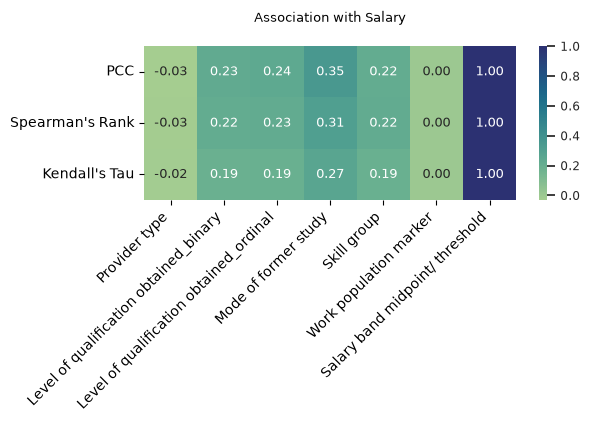

In [52]:
# Heatmap using all measures
sal_p = salary_p.transpose(); sal_s = salary_s.transpose(); sal_k = salary_k.transpose()
sal_p.index=["PCC"]; sal_s.index=["Spearman's Rank"]; sal_k.index=["Kendall's Tau"]
target_predictors_association = pd.concat([sal_p, sal_s, sal_k])

fig, ax = plt.subplots(figsize = (6, 2))
sns.set_theme(font_scale=0.8)
sns.heatmap(data=target_predictors_association, cmap="crest", annot=True, fmt=".2f", ax=ax)
ax.tick_params("x", rotation=45, rotation_mode="xtick")
ax.set_title("Association with Salary\n")
fig.show()

* In all three correlation values above, the `Mode of former study` is the predictor which has the strongest correlation with `Salary band midpoint`; graduates who studied `part-time` tended to earn higher salaries at the time they took the survey compared to those who studied `full-time`. <br>
* The `Skill group` and `Level of qualification obtained` features were approximately tied, with both having the second-highest correlation with `Salary band midpoint`. Graduates in more highly-skilled jobs earned higher salaries. Graduates who had obtained a postgraduate (taught or research) degree had higher salaries than those who had obtained an undergraduate degree. <br>
* The `Provider type` feature has a weak correlation with `Salary band midpoint`: graduates from `further education colleges (FECs)` earned higher salaries compared to those who graduated from `HEPs`. <br>
 * `Work population marker` has almost no correlation with upper `Salary band midpoint`.



#### Correlation between predictor variables
Below, heatmaps are used to show the correlation between predictor variables.

##### Pearson Correlation Coefficient

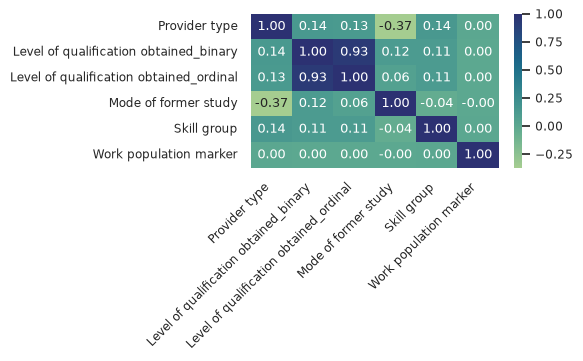

In [53]:
predictors_exclude_nominal = salary_exclude_nominal.drop(columns=["Salary band midpoint/ threshold"])

# PCC: Predictors
predictors_pearson_corr = predictors_exclude_nominal.corr()

# Heatmap
fig, ax = plt.subplots(figsize = (4, 2))
sns.set_theme(font_scale=0.8)
sns.heatmap(data=predictors_pearson_corr, cmap="crest", annot=True, fmt=".2f", ax=ax)
ax.tick_params("x", rotation=45, rotation_mode="xtick")
fig.show()

##### Spearman's Rank Correlation Coefficient

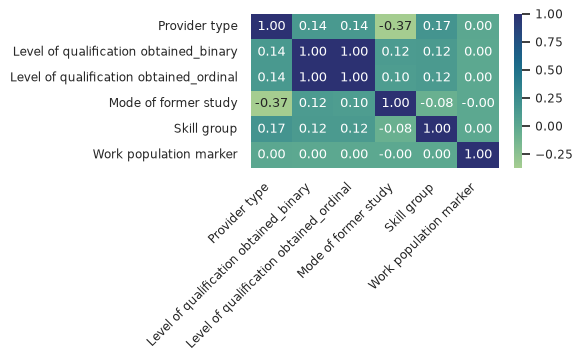

In [54]:
# Spearman's Rank: predictors
predictors_spearman_corr = predictors_exclude_nominal.corr(method = "spearman")
# Heatmap
fig, ax = plt.subplots(figsize = (4, 2))
sns.set_theme(font_scale=0.8)
sns.heatmap(data=predictors_spearman_corr, cmap="crest", annot=True, fmt=".2f", ax=ax)
ax.tick_params("x", rotation=45, rotation_mode="xtick")
fig.show()

##### Kendall's Tau

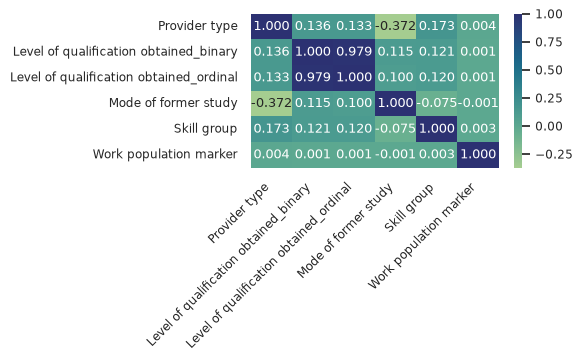

In [55]:
# Kendall's Tau: predictors
predictors_kendall = predictors_exclude_nominal.corr(method = "kendall")

# Heatmap
fig, ax = plt.subplots(figsize = (4, 2))
sns.set_theme(font_scale=0.8)
sns.heatmap(data=predictors_kendall, cmap="crest", annot=True, fmt=".3f", ax=ax)
ax.tick_params("x", rotation=45, rotation_mode="xtick")
fig.show()

* All three heatmaps show that there is a moderately strong correlation between `Provider type` and `Mode of former study`: having studied at `FECs` is positively correlated with having studied `part-time`. <br>
* There is also a weak correlation between `Provider type` and `Skill group`. Having graduated from `HEPs` as opposed to `FECs` is positively correlated with working in a more highly-skilled job at the time of survey completion.<br>
* There is a weak correlation between `Level of qualification obtained` and each of `Provider type`, `Mode of former study` and `Skill group`: graduating with a postgraduate qualification is positively correlated with graduating from a `HEP`, having studied `part-time`, and being in a more highly-skilled job at the time of survey completion. <br>
* The `Work population marker` has almost no correlation with any of the other binary and ordinal predictor variables.

### Univariate analysis

#### The target variable

The target variable is `Salary band`. Earlier, this variable was transformed and renamed to `Salary band midpoint/ threshold` (thresholds were used instead of midpoints for the highest and lowest bands, which contain censored data).

In [56]:
from statsmodels.stats import descriptivestats

# Summary statistics
salary_explore["Salary band midpoint/ threshold"] = salary_explore["Salary band midpoint/ threshold"].astype("Int64")

descriptive_stats = descriptivestats.describe(
    salary_explore["Salary band midpoint/ threshold"],
    stats=["median", "iqr", "percentiles", "mode", "top", "mean", "std"],
    percentiles = [5, 10, 25, 50, 75, 90, 95])

median_abs_dev= scipy.stats.median_abs_deviation(salary_explore["Salary band midpoint/ threshold"]) # calculate median absolute deviation
new_record = pd.DataFrame([[median_abs_dev]], index=["median abs. deviation"], columns = descriptive_stats.columns)
stats_df = pd.concat([descriptive_stats, new_record])  # add to remaining values
stats_df = stats_df.transpose()
display(stats_df)

,median,iqr,mode,mode_freq,mean,std,5%,10%,25%,50%,75%,90%,95%,median abs. deviation
Salary band midpoint/ threshold,28499.0,12000.0,25499.0,0.172336,29560.655714,8551.133274,19499.0,19499.0,22499.0,28499.0,34499.0,40499.0,49499.0,6000.0


Using salary band midpoint values, and thresholds for the highest and lowest bands, the median salary is approximately £28500, corresponding to a salary band of £27000–£29999. The median absolute deviation (a robust measure of variability) is £6000.

The mean salary is £29561, and the standard deviation is £8551.

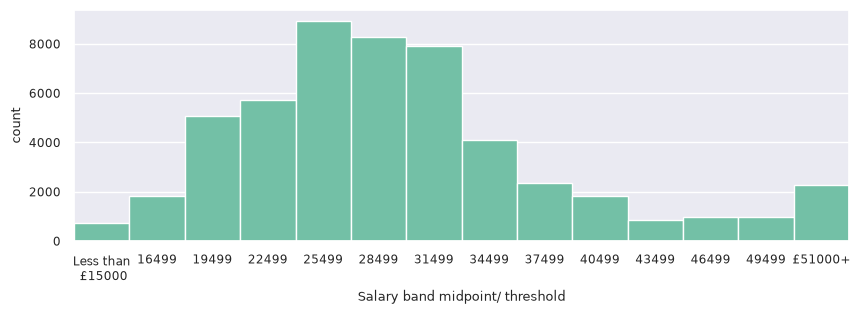

In [57]:
# Count plot
fig, ax = plt.subplots(figsize=(10,3))
sns.countplot(data=salary_numerical, x=salary_numerical["Salary band midpoint/ threshold"], color="mediumaquamarine", width = 1, ax=ax)
# Renaming highest and lowest bands using threshold values
xlabels = ax.get_xticklabels()
xlabels[-1].set_text("£51000+"); xlabels[0].set_text("Less than\n £15000")
ax.set_xticklabels(xlabels)
# Renaming x-axis to 'Salary band midpoint' (threshold values have now been labelled on plot)
ax.set(xlabel="Salary band midpoint/ threshold")
fig.show()

In [58]:
# Salary band of prominent peak
for key, value in salary_band_dict.items():
    if value == 25499:
        print(key)

£24,000 - £26,999


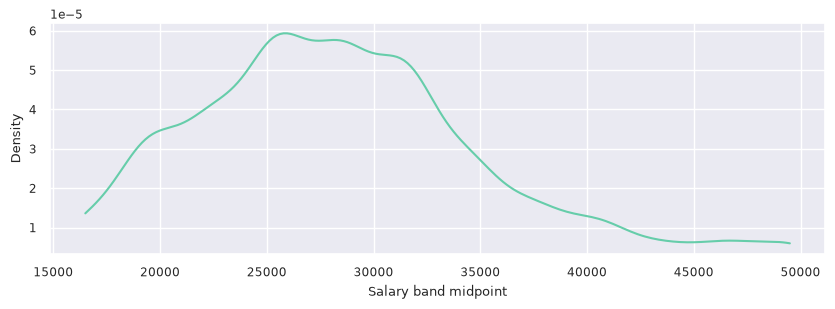

In [59]:
# KDE plot
fig, ax = plt.subplots(figsize=(10,3))
sns.kdeplot(data=salary_numerical_middle["Salary band midpoint/ threshold"], bw_adjust=1.8, label="Salary band midpoint/ threshold", cut = 0, color = "mediumaquamarine", ax=ax)
ax.set(xlabel="Salary band midpoint")
fig.show()

In [60]:
# Skew and kurtosis
salary_skew=salary_numerical_middle["Salary band midpoint/ threshold"].skew()
salary_kurtosis=salary_numerical_middle["Salary band midpoint/ threshold"].kurtosis()
print(f"skew: {salary_skew:.2f}, kurtosis: {salary_kurtosis:.2f}")

skew: 0.70, kurtosis: 0.39


The count plot includes all salary bands. Graduate salary data had been right- and left- censored, which artificially raises the count for the final bin.

The count plot and KDE plot show a prominent peak which corresponds to salary band of £24,000–£26,999.

The KDE plot excludes the lowest and highest salary bands, which contain the right- and left- censored data. Therefore, the plot displays only part of the `Salary band midpoint` distribution. With a skew value of 0.70, it is moderately right-skewed compared to a normal distribution. This appears to be a typical feature of income distributions. It has a kurtosis of 0.39 (Fisher's definition of kurtosis is used, where the kurtosis of a normal distribution is 0), indicating that the distribution has heavier tails compared to the normal distribution.

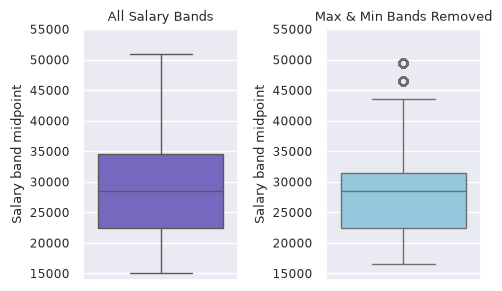

In [61]:
# Box plots
fig, ax = plt.subplot_mosaic(mosaic = "AABB", layout = "tight", figsize=(5, 3))
sns.boxplot(data = salary_numerical["Salary band midpoint/ threshold"], ax = ax["A"], color = "slateblue") # all salary bands
sns.boxplot(data = salary_numerical_middle["Salary band midpoint/ threshold"], ax = ax["B"], color = "skyblue") # max & min bands removed
ax["A"].set(ylim=(14000, 55000), title="All Salary Bands", ylabel="Salary band midpoint")
ax["B"].set(ylim=(14000, 55000), title="Max & Min Bands Removed", ylabel="Salary band midpoint")
fig.show()

For the box plot on the left, all salary bands have been included, including those with right- and left-censored data. For the box plot to the right, the highest and lowest salary bands containing right- and left-censored data have been removed.

For the plot on the left, the median salary is £28500, and the IQR is £12000, as shown earlier in the summary statistics. <br>

For the plot on the right, the median salary remains unchanged, while the IQR is narrower at £9000. Removing the highest and lowest salary bands results in lower values for the upper quartile and upper whisker.

##### Censored salary values
The `Salary band` variable has been censored by the dataset's authors.
* This variable is interval-censored, as the salaries of the graduates have been binned into 14 salary bands, each with a width of £3000 (except for the first and last bins).<br>
* Additionally, the salary variable is right-censored, as all salaries equal to and above £51,000 have been placed into the same `Salary band`. <br>
* It is also left-censored, as all salaries below £15,000 have been placed into the same `Salary band`. However, this threshold value is very close to minimum wage for full-time employees, and the dataset only includes full-time employees.

The proportion of right- and left-censored graduates in the training set is shown below. The greater the proportion of right- and left- censored values, the greater the effect it is expected to have on the analysis.


In [62]:
highest_earners = len(salary_numerical.query("`Salary band midpoint/ threshold` == 51000"))
percent_highest_earners = (highest_earners/ len(salary_numerical)) * 100

print(f"The number of graduates earning salaries at or above £51,000 is {highest_earners}.")
print(f"That is {percent_highest_earners:.2f}% of all graduates in the training set.")

The number of graduates earning salaries at or above £51,000 is 2266.
That is 4.37% of all graduates in the training set.


In [63]:
lowest_earners = len(salary_numerical.query("`Salary band midpoint/ threshold` == 14999"))
percent_lowest_earners = (lowest_earners/ len(salary_numerical)) * 100

print(f"The number of graduates earning salaries below £15000 is {lowest_earners}.")
print(f"That is {percent_lowest_earners:.2f}% of all graduates in the training set.")

The number of graduates earning salaries below £15000 is 713.
That is 1.38% of all graduates in the training set.


4.37% of graduates in full-time employment earned £51000 and above, whereas only 1.38% earned below £15000.

##### Outlier handling
Observations with salaries which were extremely high or extremely low had been removed by the authors of the dataset for quality reasons.

#### Subject area of degree

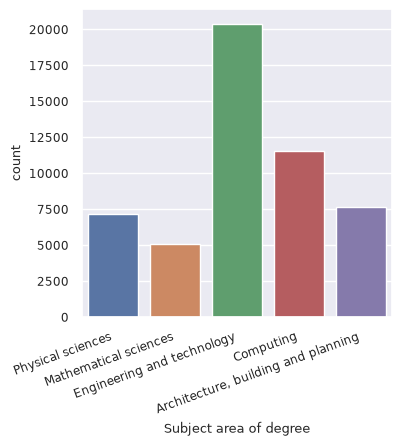

In [64]:
# Count plot
fig, ax = plt.subplots(figsize=(4,4))
sns.countplot(salary_numerical, x = "Subject area of degree", hue= "Subject area of degree", ax = ax)
ax.tick_params("x", rotation=20, rotation_mode="xtick") #tilt x-labels
fig.show()

Most graduates received a qualification in `Engineering and technology`, followed by `Computing`.

#### Country of provider

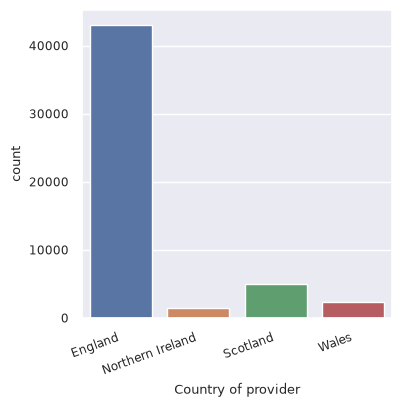

In [65]:
# Count plot
fig, ax = plt.subplots(figsize=(4,4))
sns.countplot(salary_numerical, x = "Country of provider", hue = "Country of provider", ax = ax)
ax.tick_params("x", rotation=20, rotation_mode="xtick") #tilt x-labels
fig.show()

The majority of graduates in the dataset obtained their qualification from a provider in `England`.

#### Provider type

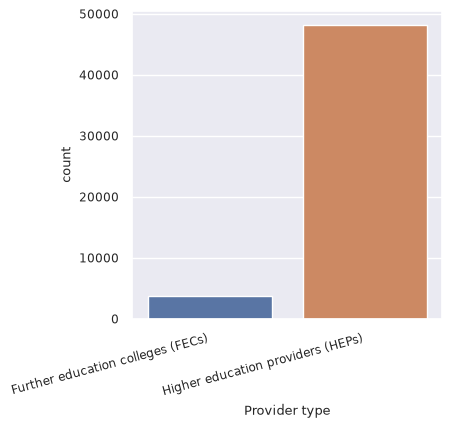

In [66]:
# Count plot
fig, ax = plt.subplots(figsize=(4,4))
sns.countplot(salary_explore, x = "Provider type", hue = "Provider type", ax = ax)
ax.tick_params("x", rotation=15, rotation_mode="xtick") #tilt x-labels
fig.show()

In [67]:
for val in salary_explore["Provider type"].value_counts(): # percentage calculation
    print(f"{val/len(salary_explore) * 100:.0f}%")

93%
7%


93% of the graduates who were included in the dataset graduated from a `HEP`, and only 7% graduated from a `FEC`.

#### Level of qualification obtained

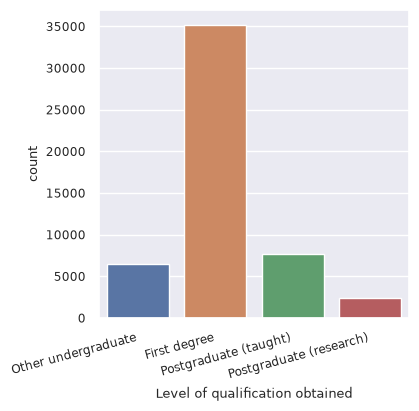

In [68]:
# Count plot
fig, ax = plt.subplots(figsize=(4,4))
sns.countplot(salary_explore, x = "Level of qualification obtained", hue = "Level of qualification obtained", ax = ax)
ax.tick_params("x", rotation=15, rotation_mode="xtick") #tilt x-labels
fig.show()

The majority of graduates included in the dataset had graduated with a `First degree`, with fewer respondents having graduated with the other qualification types.

#### Mode of former study

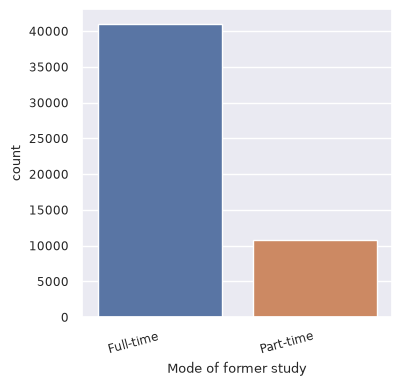

In [69]:
# Count plot
fig, ax = plt.subplots(figsize=(4,4))
sns.countplot(salary_explore, x = "Mode of former study", hue = "Mode of former study", ax = ax)
ax.tick_params("x", rotation=15, rotation_mode="xtick") #tilt x-labels
fig.show()

Among the graduates included in the dataset, approximately four times as many graduates studied `full-time` as those who studied `part-time`.

#### Skill group

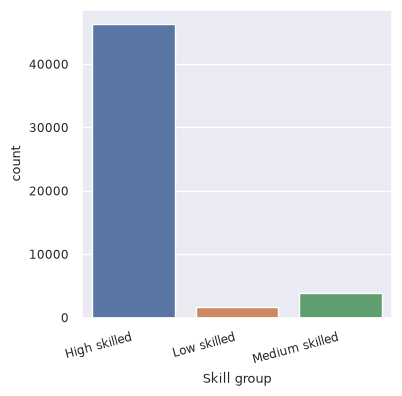

In [70]:
# Count plot
fig, ax = plt.subplots(figsize=(4,4))
sns.countplot(salary_explore, x = "Skill group", hue = "Skill group", ax = ax)
ax.tick_params("x", rotation=15, rotation_mode="xtick") #tilt x-labels
fig.show()

In [71]:
for val in salary_explore["Skill group"].value_counts(): # percentage calculation
    print(f"{val/len(salary_explore) * 100:.0f}%")

89%
7%
3%


The majority of graduates in the dataset who were in full-time paid employment were in `high skilled` roles (approximately 90%). Fewer graduates were in `medium skilled` and `low skilled` roles (approximately 7% and 3% respectively).

#### Work population marker

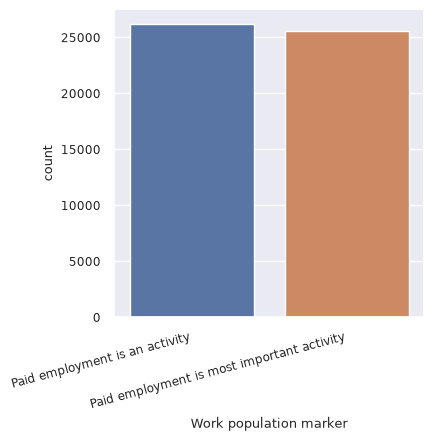

In [72]:
# Count plot
fig, ax = plt.subplots(figsize=(4,4))
sns.countplot(salary_explore, x = "Work population marker", hue = "Work population marker", ax = ax)
ax.tick_params("x", rotation=15, rotation_mode="xtick") #tilt x-labels
fig.show()

Graduates in the dataset are almost equally split between the two categories under `Work population marker`. Slightly more graduates reported that paid employment is simply `an activity` instead of their most important activity.

### Relationships between predictors and outcome

The relationship between each of the predictor variables and the `Salary band midpoint/ threshold` is described below.<br>

The KDE plots shown in this section use the trimmed training set, from which observations with right- and left-censored salary values have been removed. The remaining plots and descriptive statistics within this section use the complete training set.

#### Subject area of degree

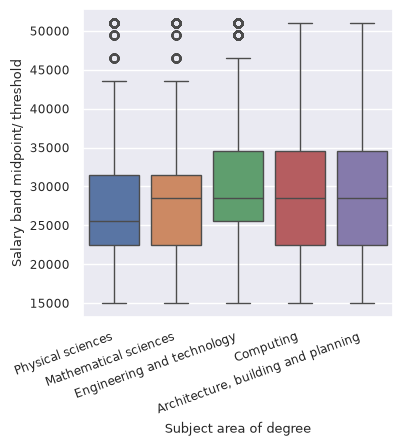

In [73]:
# Box plots: Subject area of degree and salary
fig, ax = plt.subplots(figsize = (4, 4))
sns.boxplot(data=salary_numerical[["Subject area of degree", "Salary band midpoint/ threshold"]], x = "Subject area of degree", y = "Salary band midpoint/ threshold", hue = "Subject area of degree", legend=False, ax=ax)
ax.tick_params("x", rotation=20, rotation_mode="xtick") #tilt x-labels
fig.show()

In [74]:
# Summary statistics: Subject area of degree and Salary
def categorical_stats(input_df, input_col, num_var):
    series = []
    for cat in input_df[input_col].unique():
        dataq = input_df[input_df[input_col] == cat] # extract records for given category from dataset
        summary_stats= (
        descriptivestats.describe(dataq[num_var], categorical=False, stats=["nobs", "median", "iqr", "percentiles", "mode", "top", "mean", "std", "coef_var"],
        percentiles = [5, 10, 25, 50, 75, 90, 95])).round(2).transpose() # calculate summary statistics for numerical target variable (e.g. salary)
        summary_stats.insert(loc=0, column=input_col, value= cat) # label record with name of given category
        median_abs_dev= scipy.stats.median_abs_deviation(dataq[num_var]) # calculate median absolute deviation for numerical target variable
        summary_stats.insert(loc= len(summary_stats.columns), column="median abs. deviation", value = median_abs_dev)
        series.append(summary_stats) # append summary statistics for all categories in column into one list
        concat = pd.concat(series) # combine list into one DataFrame
        concat.set_index(keys=input_col, drop=True, inplace=True) # drop existing index, so that index is set to category names (inserted earlier at loc=0)
    return concat

stat_table = categorical_stats(salary_numerical, "Subject area of degree", "Salary band midpoint/ threshold")
display(stat_table)

,nobs,median,iqr,mode,mode_freq,mean,std,coef_var,5%,10%,25%,50%,75%,90%,95%,median abs. deviation
Subject area of degree,,,,,,,,,,,,,,,,
Physical sciences,7142.0,25499.0,9000.0,25499.0,0.17,27201.48,7560.54,0.28,16499.0,19499.0,22499.0,25499.0,31499.0,37499.0,40499.0,6000.0
Mathematical sciences,5071.0,28499.0,9000.0,25499.0,0.18,28581.27,7816.86,0.27,19499.0,19499.0,22499.0,28499.0,31499.0,37499.0,46499.0,6000.0
Engineering and technology,20394.0,28499.0,9000.0,28499.0,0.19,30938.82,8531.04,0.28,19499.0,22499.0,25499.0,28499.0,34499.0,43499.0,51000.0,3000.0
Computing,11556.0,28499.0,12000.0,25499.0,0.18,28888.97,8995.82,0.31,16499.0,19499.0,22499.0,28499.0,34499.0,43499.0,49499.0,6000.0
"Architecture, building and planning",7637.0,28499.0,12000.0,25499.0,0.18,29753.33,8575.51,0.29,19499.0,19499.0,22499.0,28499.0,34499.0,43499.0,49499.0,6000.0


Four of the subject areas have the same median salary, approximately £28500, while `Physical sciences` has the lowest median salary, approximately £25500. Therefore, median values are perhaps of limited use in distinguishing between the different subject areas in terms of graduate salaries.<br>

 The subject areas, ordered from high to low in terms of mean graduate salary, are: `Engineering and technology`, then `Architecture, building and planning`, `Computing`, `Mathematical sciences`, and finally `Physical sciences`. The difference in mean graduate salary, between the category with the highest mean salary and the one with the lowest, is £3737.

The variability, or dispersion, in graduate salaries appears to be greatest for `Computing` and `Architecture, building and planning` graduates, as shown by the IQR and standard deviation. Salaries for `Mathematical sciences` and `Physical sciences` graduates have the lowest variability in graduate salaries, in terms of the IQR and standard deviation.

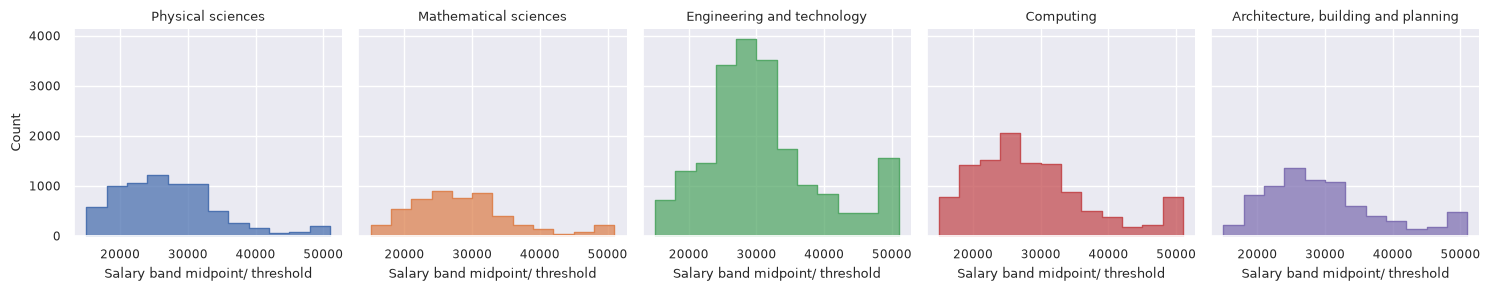

In [75]:
# Histograms: Subject area and salary (all salary bands)
stacked_hist = sns.FacetGrid(salary_numerical, col="Subject area of degree", hue="Subject area of degree")
stacked_hist.map_dataframe(sns.histplot, x="Salary band midpoint/ threshold", binwidth=3000, element="step")
stacked_hist.set_titles("{col_name}")
plt.show()

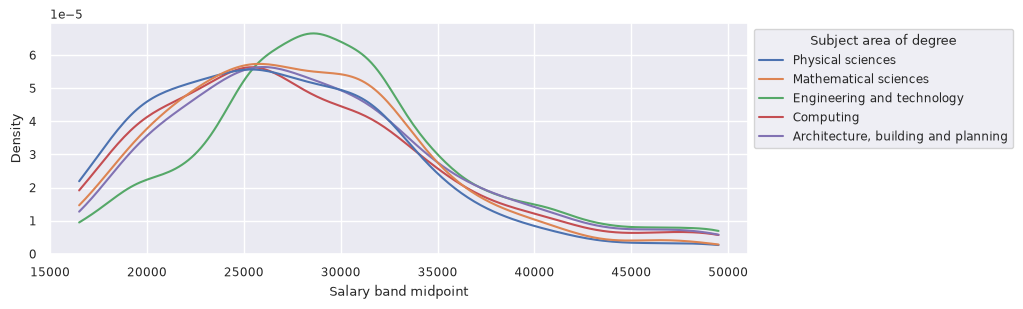

In [76]:
# KDE plot: Subject area and salary (highest and lowest salary bands removed)
fig, ax = plt.subplots(figsize = (9, 3))
for subject in salary_numerical_middle["Subject area of degree"].value_counts().index:
    sns.kdeplot(data = salary_numerical_middle[salary_numerical_middle["Subject area of degree"] == subject], x = "Salary band midpoint/ threshold", hue = salary_numerical_middle["Subject area of degree"], bw_adjust = 1.7, cut=0, ax=ax)
ax.axes.set(xlim=[14999, 50999], xlabel="Salary band midpoint")
sns.move_legend(ax, "upper left", bbox_to_anchor=(1,1))

In [77]:
for cat in salary_numerical_middle["Subject area of degree"].unique():
    data =salary_numerical_middle[salary_numerical_middle["Subject area of degree"] == cat]
    print(f"{cat}, skew: {data["Salary band midpoint/ threshold"].skew():.2f} kurtosis: {data["Salary band midpoint/ threshold"].kurtosis():.2f}.")

Physical sciences, skew: 0.72 kurtosis: 0.58.
Mathematical sciences, skew: 0.68 kurtosis: 0.55.
Engineering and technology, skew: 0.66 kurtosis: 0.42.
Computing, skew: 0.79 kurtosis: 0.35.
Architecture, building and planning, skew: 0.76 kurtosis: 0.27.


`Salary band midpoint` distributions are right-skewed for all subject areas.

#### Country of provider

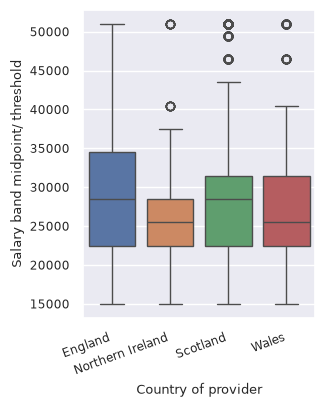

In [78]:
# Box plots: Country of provider and salary
fig, ax = plt.subplots(figsize = (3, 4))
sns.boxplot(data=salary_numerical[["Country of provider", "Salary band midpoint/ threshold"]], x = "Country of provider", y = "Salary band midpoint/ threshold", hue = "Country of provider", legend=False, ax=ax)
ax.tick_params("x", rotation=20, rotation_mode="xtick") #tilt x-labels
fig.show()

In [79]:
# Summary statistics: Country of provider and salary
stat_table = categorical_stats(salary_numerical, "Country of provider", "Salary band midpoint/ threshold") # function defined earlier
display(stat_table)

,nobs,median,iqr,mode,mode_freq,mean,std,coef_var,5%,10%,25%,50%,75%,90%,95%,median abs. deviation
Country of provider,,,,,,,,,,,,,,,,
England,43089.0,28499.0,12000.0,25499.0,0.17,29879.61,8732.60,0.29,19499.0,19499.0,22499.0,28499.0,34499.0,43499.0,49499.0,6000.0
Northern Ireland,1399.0,25499.0,6000.0,25499.0,0.29,25690.93,5198.06,0.20,19499.0,19499.0,22499.0,25499.0,28499.0,31499.0,34499.0,3000.0
Scotland,5035.0,28499.0,9000.0,28499.0,0.20,28832.11,7965.07,0.28,16499.0,19499.0,22499.0,28499.0,31499.0,40499.0,49499.0,3000.0
Wales,2277.0,25499.0,9000.0,25499.0,0.21,27513.52,6860.78,0.25,19499.0,19499.0,22499.0,25499.0,31499.0,34499.0,40499.0,3000.0


Those who graduated from a provider in `England` or `Scotland` had a higher median salary compared to those who graduated from a provider in `Northern Ireland` and `Wales`. The difference in median graduate salary, between the category with the highest median salary and the one with the lowest, is £3000.

The highest mean salary was earned by graduates from providers in `England`, followed by `Scotland`, then `Wales`, and finally `Northern Ireland`. The difference in mean graduate salary, between the category with the highest mean salary and the one with the lowest, is £4189.

At the 75th, 90th and 95th percentiles, the differences in the percentile values between the `Country of provider` categories are more pronounced. For example, at the 95th percentile, the value of the 95th percentile is £34499 for `Northern Ireland`, and £49499 for `England` and `Scotland`: a difference of £15000.

Salaries earned by graduates from providers in `England` have the greatest variability, as shown by the IQR and standard deviation, followed by salaries earned by graduates from providers in `Scotland`, followed by `Wales` (which has the same IQR as `Scotland`, but a lower standard deviation). Salaries earned by graduates from providers in `Northern Ireland` show the lowest variability.

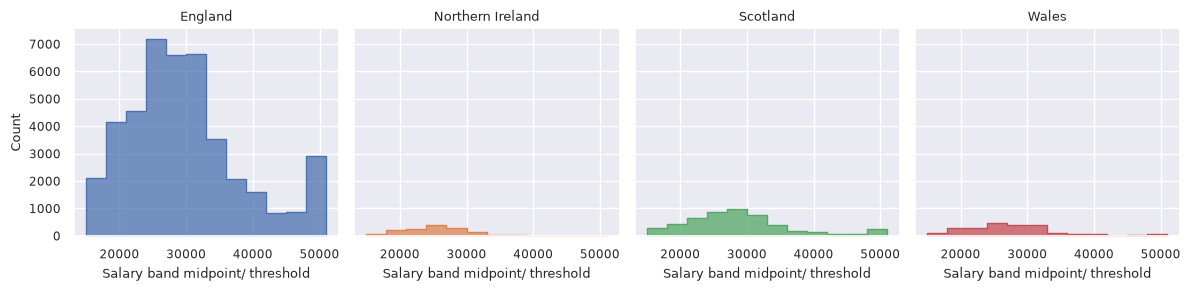

In [80]:
# Histograms: Country of provider and salary
stacked_hist = sns.FacetGrid(salary_numerical, col="Country of provider", hue="Country of provider")
stacked_hist.map_dataframe(sns.histplot, x="Salary band midpoint/ threshold", binwidth=3000, element="step")
stacked_hist.set_titles("{col_name}")
plt.show()

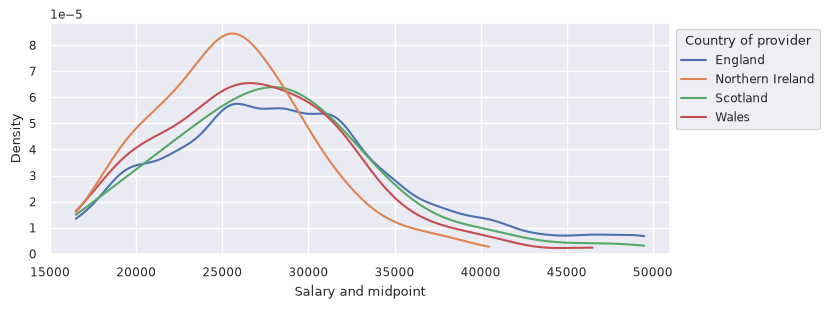

In [81]:
# KDE plots: Country of provider and salary (highest and lowest salary bands removed)
fig, ax = plt.subplots(figsize = (8, 3))
for category in salary_numerical_middle["Country of provider"].value_counts().index:
    sns.kdeplot(data = salary_numerical_middle[salary_numerical_middle["Country of provider"] == category], x = "Salary band midpoint/ threshold", bw_adjust=1.7, hue = salary_numerical_middle["Country of provider"], cut=0, ax=ax)
ax.axes.set(xlim=[15000, 51000], xlabel="Salary and midpoint")
sns.move_legend(ax, "upper left", bbox_to_anchor=(1,1))
fig.show()

In [82]:
for cat in salary_numerical_middle["Country of provider"].unique():
    data =salary_numerical_middle[salary_numerical_middle["Country of provider"] == cat]
    print(f"{cat}, skew: {data["Salary band midpoint/ threshold"].skew()}, kurtosis: {data["Salary band midpoint/ threshold"].kurtosis()}")

England, skew: 0.6738494886676714, kurtosis: 0.2603157020030049
Northern Ireland, skew: 0.4268070009227661, kurtosis: 0.19750812761065806
Scotland, skew: 0.6797354687976531, kurtosis: 0.7744834445466378
Wales, skew: 0.5577487709522004, kurtosis: 0.5415290939986117


In [83]:
salary_numerical_middle[salary_numerical_middle["Country of provider"] == "Northern Ireland"]["Salary band midpoint/ threshold"].max()

np.int64(40499)

The distribution for graduates from `Northern Ireland` providers has lighter tails compared to graduates from providers in the remaining three countries. <br>

Additionally, when the highest salary band is removed, the highest salary band midpoint value for graduates from `Northern Ireland` is just £40499, corresponding to a salary band of £39000–£42000. This is lower than the highest salary band for graduates from providers in the other countries.

#### Provider type

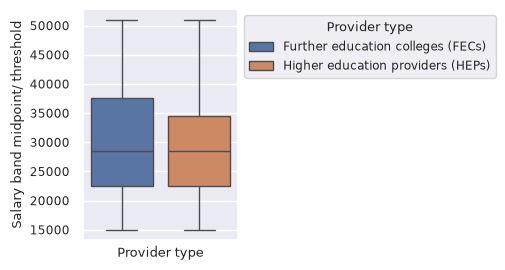

In [84]:
# box plots: Provider type
fig, ax = plt.subplots(figsize = (2, 3))
sns.boxplot(data=salary_explore[["Provider type", "Salary band midpoint/ threshold"]], x = "Provider type", y = "Salary band midpoint/ threshold", hue = "Provider type", legend=True, ax=ax)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1,1))
ax.set(xticks=[])
fig.show()

In [85]:
# Summary statistics: Provider type and salary
stat_table = categorical_stats(salary_explore, "Provider type", "Salary band midpoint/ threshold") # function defined earlier
display(stat_table)

,nobs,median,iqr,mode,mode_freq,mean,std,coef_var,5%,10%,25%,50%,75%,90%,95%,median abs. deviation
Provider type,,,,,,,,,,,,,,,,
Further education colleges (FECs),3709.0,28499.0,15000.0,25499.0,0.14,30552.70,9474.95,0.31,16499.0,19499.0,22499.0,28499.0,37499.0,46499.0,49499.0,6000.0
Higher education providers (HEPs),48091.0,28499.0,12000.0,25499.0,0.17,29484.14,8470.99,0.29,19499.0,19499.0,22499.0,28499.0,34499.0,40499.0,49499.0,6000.0


Those who graduated from `FECs` had the same median salary as those who graduated from `HEPs`, corresponding to a `Salary band` of £27000–£3000, which is the same as the median `Salary band` value for the dataset overall. However, they had a higher mean `Salary band midpoint/ threshold` compared to graduates who had studied at `HEPs`, which is higher by approximately £1000. <br>

There is also a higher variability, in terms of IQR and standard deviation, in the salaries of `FEC` graduates compared to `HEP` graduates.

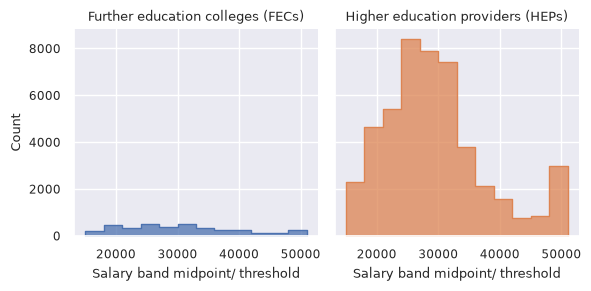

In [86]:
# Histograms: Provider type and salary
stacked_hist = sns.FacetGrid(salary_explore, col="Provider type", hue="Provider type")
stacked_hist.map_dataframe(sns.histplot, x="Salary band midpoint/ threshold", binwidth=3000, element="step")
stacked_hist.set_titles("{col_name}")
plt.show()

In [87]:
# Removing highest and lowest salary bands from DataFrame, whilst keeping all categorical values in string representation
salary_kde = salary_explore.copy()
salary_kde = salary_kde[(salary_kde["Salary band midpoint/ threshold"] != 14999) & (salary_kde["Salary band midpoint/ threshold"] != 51000)]

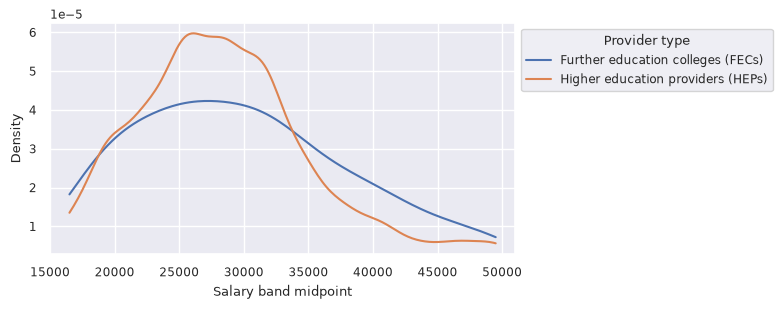

In [88]:
# KDE plots: Provider type and salary (highest and lowest salary bands removed)
fig, ax = plt.subplots(figsize = (6, 3))
for provider in salary_kde["Provider type"].unique():
    sns.kdeplot(data = salary_kde[salary_kde["Provider type"] == provider], x = "Salary band midpoint/ threshold", bw_adjust = 1.9, hue = salary_kde["Provider type"], cut=0, ax=ax)
ax.axes.set(xlim=[15000, 51000], xlabel="Salary band midpoint")
sns.move_legend(ax, "upper left", bbox_to_anchor=(1,1))
fig.show()


In [89]:
for cat in salary_kde["Provider type"].unique():
    data =salary_kde[salary_kde["Provider type"] == cat]
    print(f"{cat}, skew: {data["Salary band midpoint/ threshold"].skew():.2f} kurtosis: {data["Salary band midpoint/ threshold"].kurtosis():.2f}.")

Further education colleges (FECs), skew: 0.45 kurtosis: -0.54.
Higher education providers (HEPs), skew: 0.72 kurtosis: 0.49.


The salary distribution for `HEP` graduates is more right-skewed than that for `FEC` graduates. The salary distribution for `FEC` graduates has a kurtosis of -0.54, which is lower than the kurtosis of the salary distribution for `HEP` graduates, and lower than the normal distribution's.

#### Level of qualification obtained

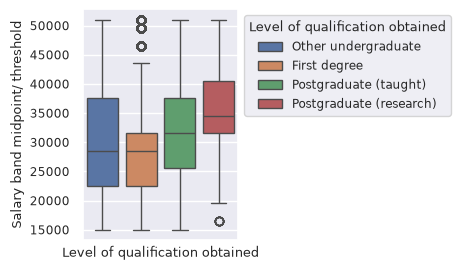

In [90]:
# Box plots: Level of qualification obtained and salary
fig, ax = plt.subplots(figsize = (2, 3))
sns.boxplot(data=salary_explore[["Level of qualification obtained", "Salary band midpoint/ threshold"]], x = "Level of qualification obtained", y = "Salary band midpoint/ threshold", hue = "Level of qualification obtained", legend=True, ax=ax)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1,1))
ax.set(xticks=[])
fig.show()

In [91]:
# Summary statistics: Level of qualification obtained and salary
stat_table = categorical_stats(salary_explore, "Level of qualification obtained", "Salary band midpoint/ threshold") # function defined earlier
display(stat_table)

,nobs,median,iqr,mode,mode_freq,mean,std,coef_var,5%,10%,25%,50%,75%,90%,95%,median abs. deviation
Level of qualification obtained,,,,,,,,,,,,,,,,
Other undergraduate,6531.0,28499.0,15000.0,25499.0,0.14,30479.99,9676.61,0.32,16499.0,19499.0,22499.0,28499.0,37499.0,46499.0,49499.0,6000.0
First degree,35216.0,28499.0,9000.0,25499.0,0.19,28261.05,7657.61,0.27,16499.0,19499.0,22499.0,28499.0,31499.0,37499.0,46499.0,3000.0
Postgraduate (taught),7670.0,31499.0,12000.0,25499.0,0.16,32654.32,9750.29,0.30,19499.0,22499.0,25499.0,31499.0,37499.0,51000.0,51000.0,6000.0
Postgraduate (research),2383.0,34499.0,9000.0,34499.0,0.23,36289.29,7551.91,0.21,25499.0,28499.0,31499.0,34499.0,40499.0,51000.0,51000.0,3000.0


Graduates who obtained a `postgraduate (research)` qualification earned the highest median salaries, followed by those who obtained a `postgraduate (taught)` qualification, and finally by graduates who obtained a `first degree` or `other undergraduate` qualification. With mean salaries, graduates who had received an `other undergraduate` qualification had a higher mean salary than those who had received a `first degree`, but otherwise a similar pattern was observed.

The difference in graduate salaries, between the category with the highest salary and the one with the lowest, is £6000 when using the median salary values for the categories, and £8028 when using their mean salary values.

`Other undergraduate` and `postgraduate (taught)` are the categories with the highest variability in graduate salaries. (The former in terms of IQR, and the latter in terms of standard deviation.)

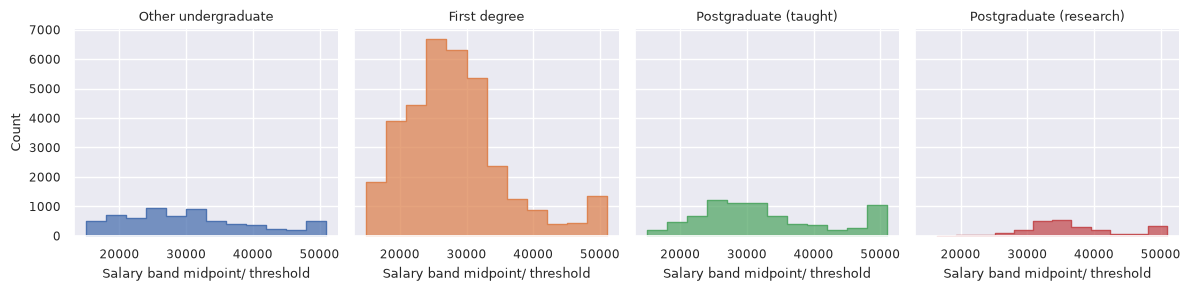

In [92]:
# Histograms: Level of qualification obtained and salary
stacked_hist = sns.FacetGrid(salary_explore, col="Level of qualification obtained", hue="Level of qualification obtained")
stacked_hist.map_dataframe(sns.histplot, x="Salary band midpoint/ threshold", binwidth=3000, element="step")
stacked_hist.set_titles("{col_name}")
plt.show()

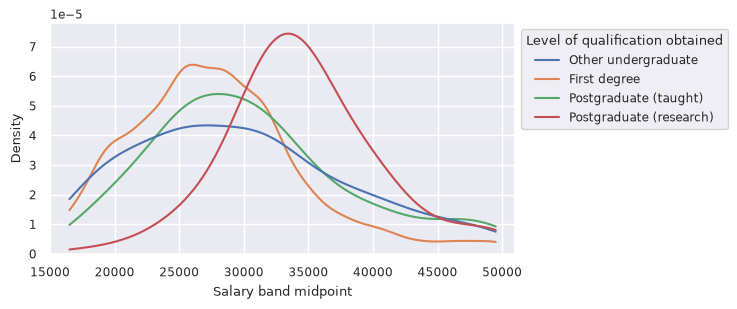

In [93]:
# KDE plots: Level of qualification obtained and salary (highest and lowest salary bands removed)
fig, ax = plt.subplots(figsize = (6, 3))
for level in salary_kde["Level of qualification obtained"].value_counts().index:
    sns.kdeplot(data = salary_kde[salary_kde["Level of qualification obtained"] == level], x = "Salary band midpoint/ threshold", bw_adjust = 1.9, hue = salary_kde["Level of qualification obtained"], cut=0, ax=ax)
ax.axes.set(xlim=[15000, 51000], xlabel="Salary band midpoint")
sns.move_legend(ax, "upper left", bbox_to_anchor=(1,1))
fig.show()

In [94]:
for cat in salary_kde["Level of qualification obtained"].unique():
    data =salary_kde[salary_kde["Level of qualification obtained"] == cat]
    print(f"{cat}, skew: {data["Salary band midpoint/ threshold"].skew():.2f} kurtosis: {data["Salary band midpoint/ threshold"].kurtosis():.2f}.")

Other undergraduate, skew: 0.47 kurtosis: -0.50.
First degree, skew: 0.79 kurtosis: 0.89.
Postgraduate (taught), skew: 0.63 kurtosis: -0.08.
Postgraduate (research), skew: 0.31 kurtosis: 0.65.


The distributions in graduate salaries for each of the four `Level of qualification obtained` categories are plotted above. The salary distribution for `First degree` graduates was the most right skewed compared to the other distributions, while for `Posgraduate (research)` graduates it showed the least right skew.

#### Mode of former study

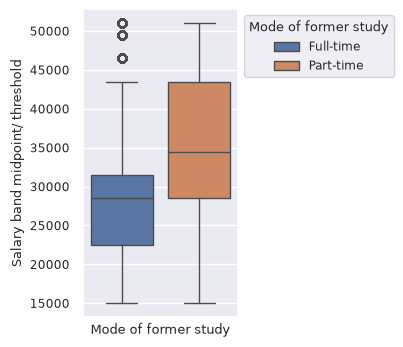

In [95]:
# Box plots: Mode of former study and salary
fig, ax = plt.subplots(figsize = (2, 4))
sns.boxplot(data=salary_explore[["Mode of former study", "Salary band midpoint/ threshold"]], x = "Mode of former study", y = "Salary band midpoint/ threshold", hue = "Mode of former study", legend=True, ax=ax)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1,1))
ax.set(xticks=[])
fig.show()

In [96]:
# Summary statistics: Mode of former study and salary
stat_table = categorical_stats(salary_explore, "Mode of former study", "Salary band midpoint/ threshold") # function defined earlier
display(stat_table)

,nobs,median,iqr,mode,mode_freq,mean,std,coef_var,5%,10%,25%,50%,75%,90%,95%,median abs. deviation
Mode of former study,,,,,,,,,,,,,,,,
Full-time,41021.0,28499.0,9000.0,25499.0,0.19,28013.78,7373.01,0.26,16499.0,19499.0,22499.0,28499.0,31499.0,37499.0,43499.0,3000.0
Part-time,10779.0,34499.0,15000.0,51000.0,0.13,35447.51,10038.15,0.28,19499.0,22499.0,28499.0,34499.0,43499.0,51000.0,51000.0,9000.0


Note that earlier, this variable was shown to have the strongest correlation with `Salary band midpoint/ threshold`, out of the binary and ordinal variables in the dataset.

Graduates who had studied `Part-time` had a higher median and mean salary than those who had studied `full-time`. The difference in median salaries is £6000, whereas the difference in mean salaries is £7434. <br>

There was also a higher variability in graduate salaries among those who `part-time` compared to those who studied `full-time`, with respect to the IQR and standard deviation values.

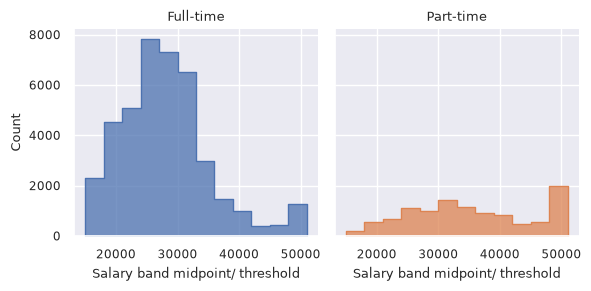

In [97]:
# Histograms: Mode of former study and salary
stacked_hist = sns.FacetGrid(salary_explore, col="Mode of former study", hue="Mode of former study")
stacked_hist.map_dataframe(sns.histplot, x="Salary band midpoint/ threshold", binwidth=3000, element="step")
stacked_hist.set_titles("{col_name}")
plt.show()

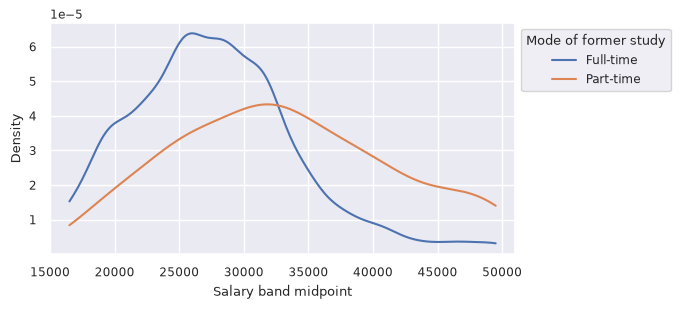

In [98]:
# KDE plots: Mode of former study and salary (highest and lowest salary bands removed)
fig, ax = plt.subplots(figsize = (6, 3))
for mode in salary_kde["Mode of former study"].unique():
    sns.kdeplot(data = salary_kde[salary_kde["Mode of former study"] == mode], x = "Salary band midpoint/ threshold", bw_adjust = 2, hue = salary_kde["Mode of former study"], cut=0, ax=ax)
ax.axes.set(xlim=[15000, 51000], xlabel="Salary band midpoint")
sns.move_legend(ax, "upper left", bbox_to_anchor=(1,1))
fig.show()

In [99]:
for cat in salary_kde["Mode of former study"].unique():
    data =salary_kde[salary_kde["Mode of former study"] == cat]
    print(f"{cat}, skew: {data["Salary band midpoint/ threshold"].skew():.2f} kurtosis: {data["Salary band midpoint/ threshold"].kurtosis():.2f}.")

Full-time, skew: 0.70 kurtosis: 0.80.
Part-time, skew: 0.19 kurtosis: -0.74.


The histograms show a disproportionately high count for the highest salary band, `£51000+`, among graduates who had studied `part-time`. The count for this salary band is higher for graduates who studied `part-time` than for those who studied `full-time`, even though those who studied `part-time` only make up 20% of all graduates within the dataset.

The KDE plot above shows that the salary distribution for graduates who studied `full-time` is more right-skewed. On the other hand, the distribution for graduates who studied `part-time` is less right skewed, and has a negative kurtosis value.

#### Skill group

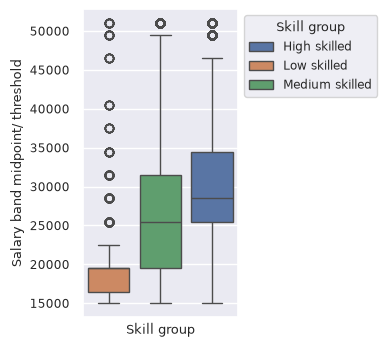

In [100]:
# box plots: Salary and Skill group
fig, ax = plt.subplots(figsize = (2, 4))
sns.boxplot(data=salary_explore[["Skill group", "Salary band midpoint/ threshold"]], x = "Skill group", y = "Salary band midpoint/ threshold", order=["Low skilled", "Medium skilled", "High skilled"], hue = "Skill group", legend=True, ax=ax)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1,1))
ax.set(xticks=[])
fig.show()

In [101]:
# Summary statistics: Skill group and salary
stat_table = categorical_stats(salary_explore, "Skill group", "Salary band midpoint/ threshold") # function defined earlier
display(stat_table)

,nobs,median,iqr,mode,mode_freq,mean,std,coef_var,5%,10%,25%,50%,75%,90%,95%,median abs. deviation
Skill group,,,,,,,,,,,,,,,,
High skilled,46292.0,28499.0,9000.0,25499.0,0.18,30110.71,8278.29,0.27,19499.0,19499.0,25499.0,28499.0,34499.0,43499.0,49499.0,3000.0
Low skilled,1687.0,19499.0,3000.0,19499.0,0.31,20210.33,6771.87,0.34,14999.0,14999.0,16499.0,19499.0,19499.0,28499.0,31499.0,3000.0
Medium skilled,3821.0,25499.0,12000.0,19499.0,0.20,27024.95,9598.37,0.36,14999.0,16499.0,19499.0,25499.0,31499.0,40499.0,49499.0,6000.0


Graduates in more highly-skilled roles have higher median and mean values for `Salary band midpoint` than those in more low-skilled roles. The difference in graduate salaries, between the category with the highest salary and the one with the lowest, is £9000 when using median salaries, and £9900 when using mean salaries.<br>

Graduates in `medium skilled` roles have the highest variability in `Salary band midpoints`, followed by graduates in `high skilled` roles, followed by those in `low skilled` roles, with respect to both IQR and standard deviation.

The box plots above show that there are a number of graduates who earned a high salary, up to and including the highest salary band, despite being in a `low skilled` role. These are shown as outliers on the box plot, lying above the upper whisker.

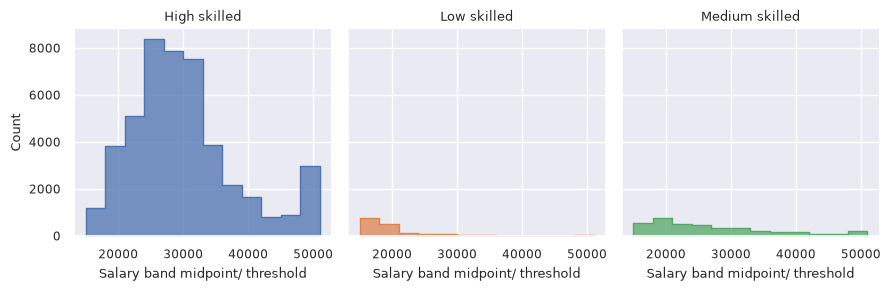

In [102]:
# Histograms: Salary and Skill group
stacked_hist = sns.FacetGrid(salary_explore, col="Skill group", hue="Skill group")
stacked_hist.map_dataframe(sns.histplot, x="Salary band midpoint/ threshold", binwidth=3000, element="step")
stacked_hist.set_titles("{col_name}")
plt.show()

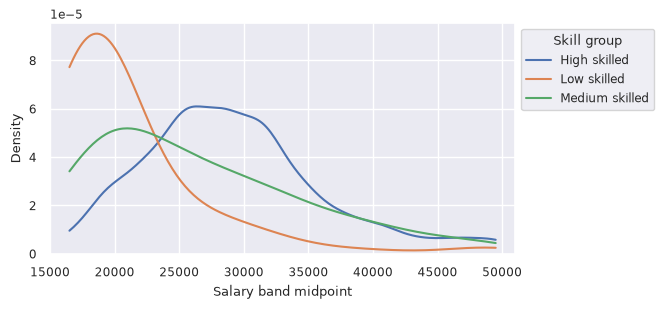

In [103]:
# KDE plots: Skill group and salary (highest and lowest salary bands removed)
fig, ax = plt.subplots(figsize = (6, 3))
for skill in salary_kde["Skill group"].unique():
    sns.kdeplot(data = salary_kde[salary_kde["Skill group"] == skill], x = "Salary band midpoint/ threshold", bw_adjust = 2, hue = salary_kde["Skill group"], cut=0, ax=ax)
ax.axes.set(xlim=[15000, 51000], xlabel="Salary band midpoint")
sns.move_legend(ax, "upper left", bbox_to_anchor=(1,1))
fig.show()

In [104]:
for cat in salary_kde["Skill group"].unique():
    data =salary_kde[salary_kde["Skill group"] == cat]
    print(f"{cat}, skew: {data["Salary band midpoint/ threshold"].skew():.2f} kurtosis: {data["Salary band midpoint/ threshold"].kurtosis():.2f}.")

High skilled, skew: 0.74 kurtosis: 0.51.
Low skilled, skew: 2.50 kurtosis: 7.38.
Medium skilled, skew: 0.87 kurtosis: 0.04.


As shown in the KDE plot and values above, the salary distribution for graduates in `low skilled` roles is more right-skewed compared to the salary distributions for graduates in `medium skilled` and `high skilled` roles. Additionally, its kurtosis is higher than the kurtosis of the other distributions.

#### Work population marker

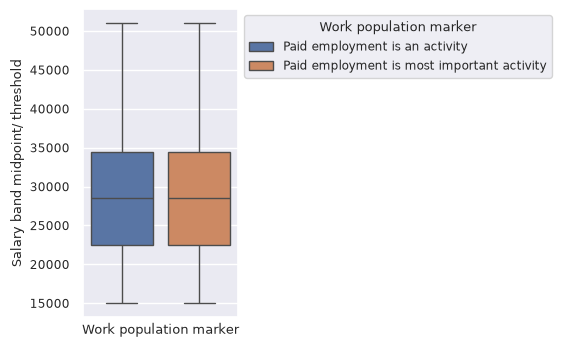

In [105]:
# Box plots: Work population marker and salary
fig, ax = plt.subplots(figsize = (2, 4))
sns.boxplot(data=salary_explore[["Work population marker", "Salary band midpoint/ threshold"]], x = "Work population marker", y = "Salary band midpoint/ threshold", hue = "Work population marker", legend=True, ax=ax)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1,1))
ax.set(xticks=[])
fig.show()

In [106]:
# Summary statistics: Work population marker and salary
stat_table = categorical_stats(salary_explore, "Work population marker", "Salary band midpoint/ threshold") # function defined earlier
display(stat_table)

,nobs,median,iqr,mode,mode_freq,mean,std,coef_var,5%,10%,25%,50%,75%,90%,95%,median abs. deviation
Work population marker,,,,,,,,,,,,,,,,
Paid employment is an activity,26207.0,28499.0,12000.0,25499.0,0.17,29529.25,8551.98,0.29,19499.0,19499.0,22499.0,28499.0,34499.0,40499.0,49499.0,6000.0
Paid employment is most important activity,25593.0,28499.0,12000.0,25499.0,0.17,29592.82,8550.32,0.29,19499.0,19499.0,22499.0,28499.0,34499.0,40499.0,49499.0,6000.0


Earlier, it was shown that the `Work population marker` had almost no correlation with graduate salaries.

As shown above, the `Work population marker` categories have identical graduate salary median and IQR values. The mean and standard deviation values for graduate salaries are nearly identical between the two categories. <br>

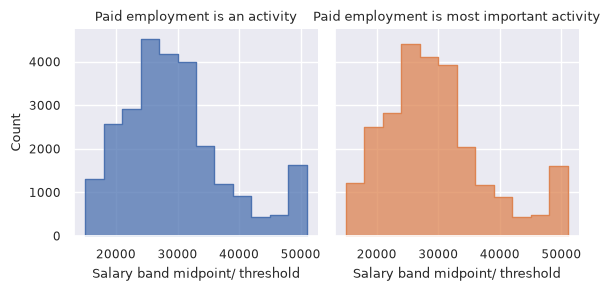

In [107]:
# Histograms: Work population marker and salary
stacked_hist = sns.FacetGrid(salary_explore, col="Work population marker", hue="Work population marker")
stacked_hist.map_dataframe(sns.histplot, x="Salary band midpoint/ threshold", binwidth=3000, element="step")
stacked_hist.set_titles("{col_name}")
plt.show()

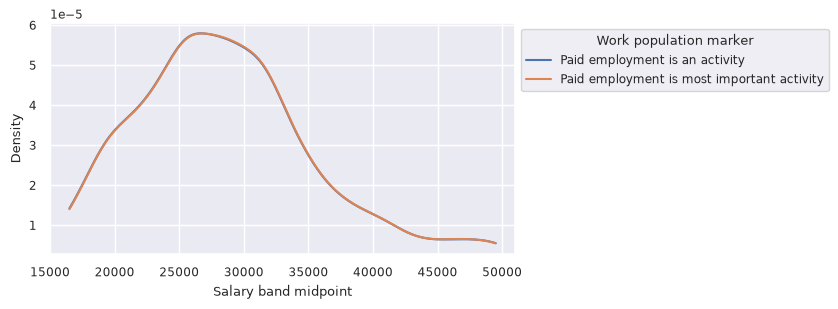

In [108]:
# KDE plots: Work population marker and salary (highest and lowest salary bands removed)
fig, ax = plt.subplots(figsize = (6, 3))
for population in salary_kde["Work population marker"].unique():
    sns.kdeplot(data = salary_kde[salary_kde["Work population marker"] == population], x = "Salary band midpoint/ threshold", bw_adjust = 1.9, hue = salary_kde["Work population marker"], cut=0, ax=ax)
ax.axes.set(xlim=[15000, 51000], xlabel="Salary band midpoint")
sns.move_legend(ax, "upper left", bbox_to_anchor=(1,1))
fig.show()

The graduate salary distributions for the two categories are almost identical.